In [4]:

import os
import random
import numpy as np
import torch
import torch.nn.functional as F
from torch.utils.data import DataLoader, random_split, Subset
from torchvision import transforms, datasets
import timm
import pytorch_lightning as pl
from pytorch_lightning.callbacks import ModelCheckpoint, EarlyStopping
from sklearn.metrics import confusion_matrix, accuracy_score
import matplotlib.pyplot as plt
import seaborn as sns

print("✅ Imports OK")


✅ Imports OK


In [6]:
SEED = 42
random.seed(SEED)
np.random.seed(SEED)
torch.manual_seed(SEED)

DATA_DIR = "AugmentedAlzheimerDataset"  # path to dataset folder
BATCH_SIZE = 32
IMG_SIZE = 224
NUM_WORKERS = 4  # use 0 if issues occur
MAX_EPOCHS = 30
LR = 5e-5

print(f"📁 DATA_DIR={DATA_DIR}")

📁 DATA_DIR=AugmentedAlzheimerDataset


In [7]:
device = "cuda" if torch.cuda.is_available() else "cpu"
print(f"🚀 Using device: {device}")


🚀 Using device: cuda


In [8]:
# Define transformations
train_transform = transforms.Compose([
    transforms.Resize((IMG_SIZE, IMG_SIZE)),
    transforms.RandomHorizontalFlip(),
    transforms.ToTensor(),
    transforms.Normalize([0.485, 0.456, 0.406], [0.229, 0.224, 0.225])
])
print (f"1")
val_transform = transforms.Compose([
    transforms.Resize((IMG_SIZE, IMG_SIZE)),
    transforms.ToTensor(),
    transforms.Normalize([0.485, 0.456, 0.406], [0.229, 0.224, 0.225])
])

# Load dataset
full_dataset = datasets.ImageFolder(root=DATA_DIR, transform=train_transform)
if len(full_dataset) == 0:
    raise RuntimeError(f"No images found in {DATA_DIR}. Check path!")

classes = full_dataset.classes
num_classes = len(classes)
print(f"✅ Found classes: {classes}")
print(f"📸 Total images: {len(full_dataset)}")

# Split into train/val
val_size = int(0.2 * len(full_dataset))
train_size = len(full_dataset) - val_size
train_dataset, val_dataset = random_split(full_dataset, [train_size, val_size], generator=torch.Generator().manual_seed(SEED))

# Assign validation transform
full_dataset_val = datasets.ImageFolder(root=DATA_DIR, transform=val_transform)
val_indices = val_dataset.indices
val_dataset = Subset(full_dataset_val, val_indices)

# DataLoaders
train_loader = DataLoader(train_dataset, batch_size=BATCH_SIZE, shuffle=True, num_workers=NUM_WORKERS)
val_loader = DataLoader(val_dataset, batch_size=BATCH_SIZE, shuffle=False, num_workers=NUM_WORKERS)

print(f"📦 Train size: {len(train_dataset)} | Val size: {len(val_dataset)} | Batch size: {BATCH_SIZE}")


1
✅ Found classes: ['MildDemented', 'ModerateDemented', 'NonDemented', 'VeryMildDemented']
📸 Total images: 33984
📦 Train size: 27188 | Val size: 6796 | Batch size: 32


In [9]:
class AlzheimerViT(pl.LightningModule):
    def __init__(self, num_classes, lr=1e-4):
        super().__init__()
        self.save_hyperparameters()
        self.model = timm.create_model("vit_base_patch16_224", pretrained=True, num_classes=num_classes)
        self.lr = lr

        # temporary storage for validation epoch
        self.val_preds = []
        self.val_labels = []

    def forward(self, x):
        return self.model(x)

    def training_step(self, batch, batch_idx):
        images, labels = batch
        outputs = self(images)
        loss = F.cross_entropy(outputs, labels)
        preds = outputs.argmax(dim=1)
        acc = (preds == labels).float().mean()

        if batch_idx % 50 == 0:
            print(f"[train] batch={batch_idx} loss={loss.item():.4f} acc={acc.item():.4f}")

        self.log('train_loss', loss, prog_bar=False, on_step=True, on_epoch=True)
        self.log('train_acc', acc, prog_bar=False, on_step=True, on_epoch=True)
        return loss

    def validation_step(self, batch, batch_idx):
        images, labels = batch
        outputs = self(images)
        loss = F.cross_entropy(outputs, labels)
        preds = outputs.argmax(dim=1)
        acc = (preds == labels).float().mean()

        # store preds and labels for confusion matrix later
        self.val_preds.append(preds.detach().cpu())
        self.val_labels.append(labels.detach().cpu())

        self.log('val_loss', loss, prog_bar=True, on_step=False, on_epoch=True)
        self.log('val_acc', acc, prog_bar=True, on_step=False, on_epoch=True)
        return loss

    def on_validation_epoch_end(self):
        # combine all preds and labels
        preds = torch.cat(self.val_preds, dim=0).numpy()
        labels = torch.cat(self.val_labels, dim=0).numpy()
        self.val_preds.clear()
        self.val_labels.clear()

        # confusion matrix + accuracy
        cm = confusion_matrix(labels, preds)
        acc = accuracy_score(labels, preds)
        print(f"\n📊 Validation accuracy (epoch end): {acc:.4f}")

        plt.figure(figsize=(6, 5))
        sns.heatmap(cm, annot=True, fmt='d', xticklabels=classes, yticklabels=classes)
        plt.xlabel('Predicted')
        plt.ylabel('Actual')
        plt.title('Confusion Matrix')
        plt.show()

    def configure_optimizers(self):
        optimizer = torch.optim.AdamW(self.parameters(), lr=self.lr)
        return optimizer

print("✅ Model class updated for PyTorch Lightning v2.x")


✅ Model class updated for PyTorch Lightning v2.x


In [10]:
model = AlzheimerViT(num_classes=num_classes, lr=LR)

checkpoint_cb = ModelCheckpoint(
    monitor='val_acc',
    mode='max',
    save_top_k=1,
    filename='alzheimer-vit-{epoch:02d}-{val_acc:.4f}'
)
earlystop_cb = EarlyStopping(monitor='val_acc', patience=3, mode='max')

trainer = pl.Trainer(
    max_epochs=MAX_EPOCHS,
    accelerator='auto',
    devices=1 if torch.cuda.is_available() else None,
    callbacks=[checkpoint_cb, earlystop_cb],
    log_every_n_steps=10,
    deterministic=True
)

print("🚀 Trainer ready")


model.safetensors:   0%|          | 0.00/346M [00:00<?, ?B/s]

GPU available: True (cuda), used: True
TPU available: False, using: 0 TPU cores
HPU available: False, using: 0 HPUs


🚀 Trainer ready


You are using a CUDA device ('NVIDIA H100 80GB HBM3') that has Tensor Cores. To properly utilize them, you should set `torch.set_float32_matmul_precision('medium' | 'high')` which will trade-off precision for performance. For more details, read https://pytorch.org/docs/stable/generated/torch.set_float32_matmul_precision.html#torch.set_float32_matmul_precision


🧠 Starting training...


LOCAL_RANK: 0 - CUDA_VISIBLE_DEVICES: [0]

  | Name  | Type              | Params | Mode 
----------------------------------------------------
0 | model | VisionTransformer | 85.8 M | train
----------------------------------------------------
85.8 M    Trainable params
0         Non-trainable params
85.8 M    Total params
343.207   Total estimated model params size (MB)
276       Modules in train mode
0         Modules in eval mode


Sanity Checking: |          | 0/? [00:00<?, ?it/s]


📊 Validation accuracy (epoch end): 0.1875


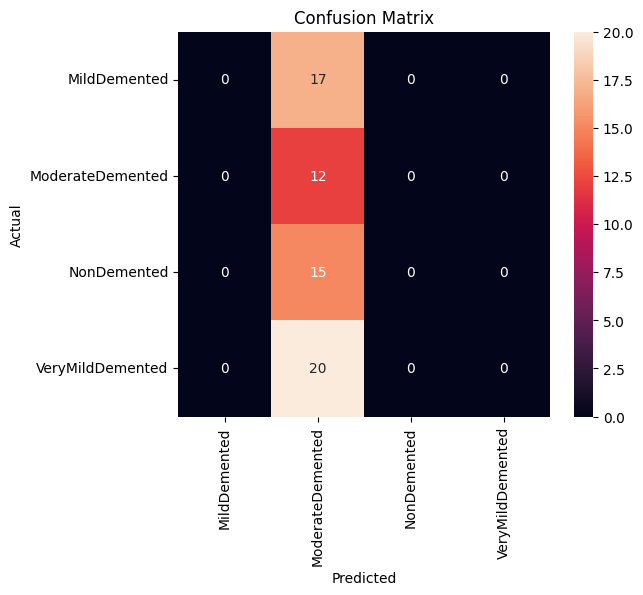

Training: |          | 0/? [00:00<?, ?it/s]

[train] batch=0 loss=2.4875 acc=0.0938
[train] batch=50 loss=1.1824 acc=0.3750
[train] batch=100 loss=1.0631 acc=0.4062
[train] batch=150 loss=0.7501 acc=0.6562
[train] batch=200 loss=0.4537 acc=0.8125
[train] batch=250 loss=0.7546 acc=0.5625
[train] batch=300 loss=0.8017 acc=0.5938
[train] batch=350 loss=0.5402 acc=0.6875
[train] batch=400 loss=0.5639 acc=0.7188
[train] batch=450 loss=0.5472 acc=0.7500
[train] batch=500 loss=0.6880 acc=0.5938
[train] batch=550 loss=0.5497 acc=0.6562
[train] batch=600 loss=0.5903 acc=0.7500
[train] batch=650 loss=0.2789 acc=0.9062
[train] batch=700 loss=0.4068 acc=0.8438
[train] batch=750 loss=0.4043 acc=0.7812
[train] batch=800 loss=0.2969 acc=0.8750


Validation: |          | 0/? [00:00<?, ?it/s]


📊 Validation accuracy (epoch end): 0.8717


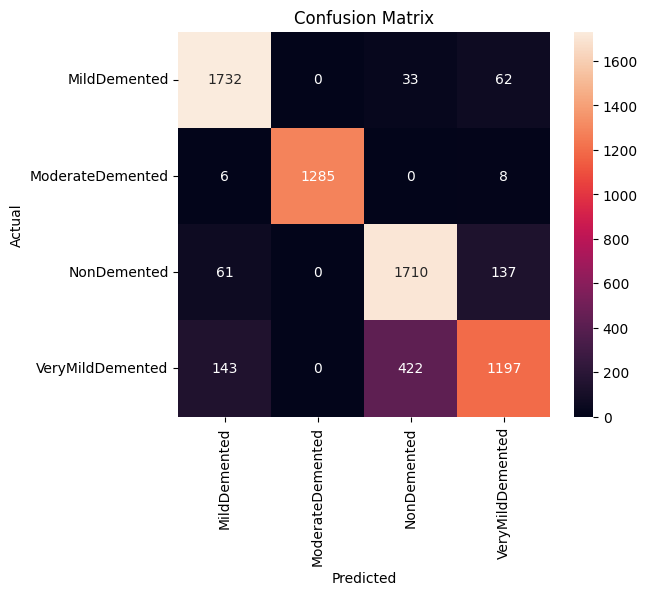

[train] batch=0 loss=0.4970 acc=0.7812
[train] batch=50 loss=0.2257 acc=0.9062
[train] batch=100 loss=0.5016 acc=0.7500
[train] batch=150 loss=0.2075 acc=0.9062
[train] batch=200 loss=0.3241 acc=0.8125
[train] batch=250 loss=0.1376 acc=0.9375
[train] batch=300 loss=0.2756 acc=0.9062
[train] batch=350 loss=0.0987 acc=0.9688
[train] batch=400 loss=0.0566 acc=1.0000
[train] batch=450 loss=0.2292 acc=0.9062
[train] batch=500 loss=0.0705 acc=1.0000
[train] batch=550 loss=0.1404 acc=0.9062
[train] batch=600 loss=0.1485 acc=0.9688
[train] batch=650 loss=0.0858 acc=0.9688
[train] batch=700 loss=0.1912 acc=0.9375
[train] batch=750 loss=0.0816 acc=0.9688
[train] batch=800 loss=0.2921 acc=0.9062


Validation: |          | 0/? [00:00<?, ?it/s]


📊 Validation accuracy (epoch end): 0.9347


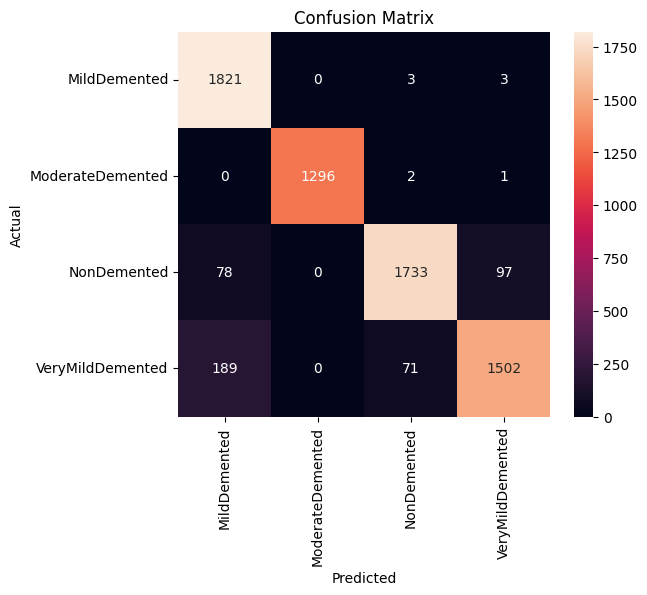

[train] batch=0 loss=0.0247 acc=1.0000
[train] batch=50 loss=0.0052 acc=1.0000
[train] batch=100 loss=0.0254 acc=1.0000
[train] batch=150 loss=0.0307 acc=1.0000
[train] batch=200 loss=0.1469 acc=0.9688
[train] batch=250 loss=0.0727 acc=0.9688
[train] batch=300 loss=0.3363 acc=0.9375
[train] batch=350 loss=0.1242 acc=0.9375
[train] batch=400 loss=0.2095 acc=0.9375
[train] batch=450 loss=0.0415 acc=1.0000
[train] batch=500 loss=0.1225 acc=0.9688
[train] batch=550 loss=0.0902 acc=0.9688
[train] batch=600 loss=0.1372 acc=0.9375
[train] batch=650 loss=0.0152 acc=1.0000
[train] batch=700 loss=0.0116 acc=1.0000
[train] batch=750 loss=0.0248 acc=1.0000
[train] batch=800 loss=0.0764 acc=0.9688


Validation: |          | 0/? [00:00<?, ?it/s]


📊 Validation accuracy (epoch end): 0.9654


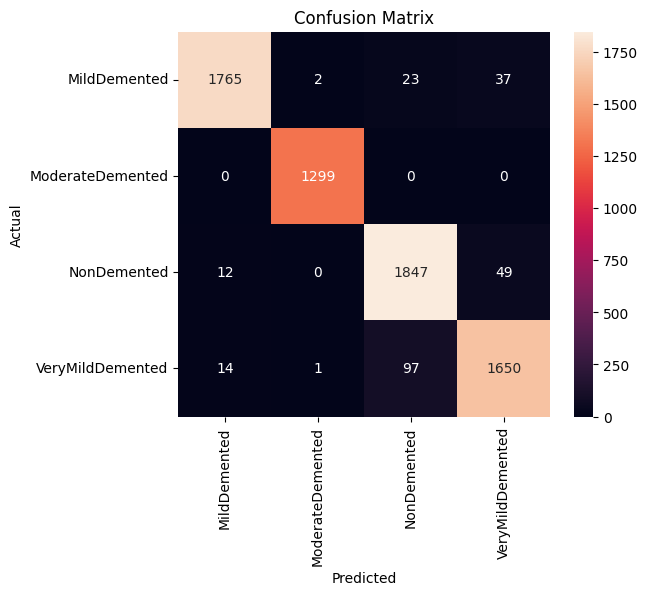

[train] batch=0 loss=0.0855 acc=0.9688
[train] batch=50 loss=0.0042 acc=1.0000
[train] batch=100 loss=0.1554 acc=0.9062
[train] batch=150 loss=0.2051 acc=0.9375
[train] batch=200 loss=0.0250 acc=1.0000
[train] batch=250 loss=0.2519 acc=0.9688
[train] batch=300 loss=0.0044 acc=1.0000
[train] batch=350 loss=0.0403 acc=1.0000
[train] batch=400 loss=0.0131 acc=1.0000
[train] batch=450 loss=0.0436 acc=1.0000
[train] batch=500 loss=0.0113 acc=1.0000
[train] batch=550 loss=0.0048 acc=1.0000
[train] batch=600 loss=0.0920 acc=1.0000
[train] batch=650 loss=0.1526 acc=0.9375
[train] batch=700 loss=0.0163 acc=1.0000
[train] batch=750 loss=0.0753 acc=0.9375
[train] batch=800 loss=0.0053 acc=1.0000


Validation: |          | 0/? [00:00<?, ?it/s]


📊 Validation accuracy (epoch end): 0.9740


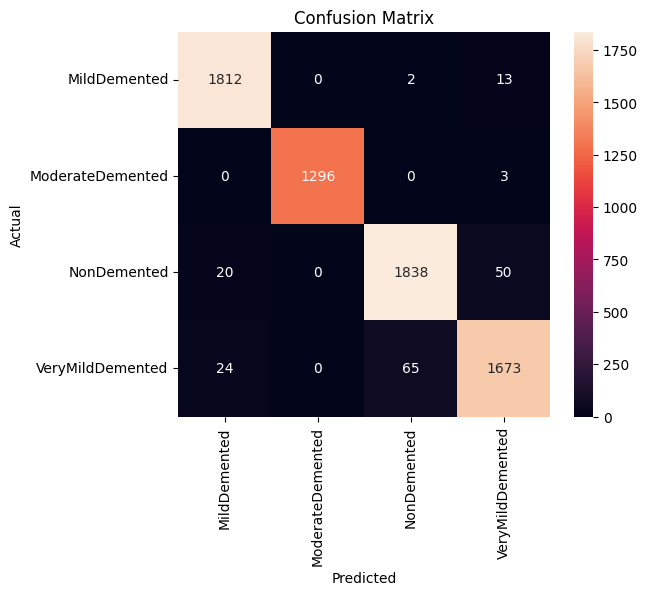

[train] batch=0 loss=0.2712 acc=0.9062
[train] batch=50 loss=0.0736 acc=0.9375
[train] batch=100 loss=0.0170 acc=1.0000
[train] batch=150 loss=0.0029 acc=1.0000
[train] batch=200 loss=0.0662 acc=0.9688
[train] batch=250 loss=0.0991 acc=0.9688
[train] batch=300 loss=0.0145 acc=1.0000
[train] batch=350 loss=0.1668 acc=0.9688
[train] batch=400 loss=0.0803 acc=0.9688
[train] batch=450 loss=0.1001 acc=0.9688
[train] batch=500 loss=0.0043 acc=1.0000
[train] batch=550 loss=0.0269 acc=1.0000
[train] batch=600 loss=0.0109 acc=1.0000
[train] batch=650 loss=0.0052 acc=1.0000
[train] batch=700 loss=0.0382 acc=0.9688
[train] batch=750 loss=0.0589 acc=0.9688
[train] batch=800 loss=0.0064 acc=1.0000


Validation: |          | 0/? [00:00<?, ?it/s]


📊 Validation accuracy (epoch end): 0.9576


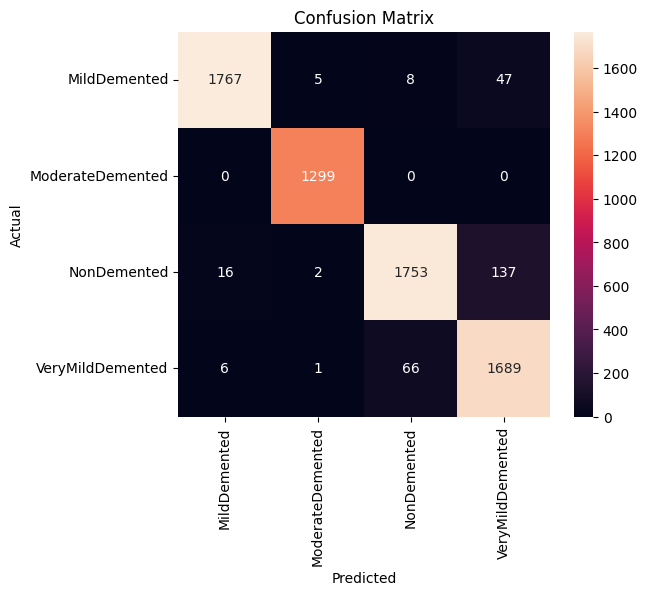

[train] batch=0 loss=0.0096 acc=1.0000
[train] batch=50 loss=0.0652 acc=0.9375
[train] batch=100 loss=0.0051 acc=1.0000
[train] batch=150 loss=0.0147 acc=1.0000
[train] batch=200 loss=0.0279 acc=1.0000
[train] batch=250 loss=0.0099 acc=1.0000
[train] batch=300 loss=0.0754 acc=0.9375
[train] batch=350 loss=0.0009 acc=1.0000
[train] batch=400 loss=0.0360 acc=0.9688
[train] batch=450 loss=0.1118 acc=0.9688
[train] batch=500 loss=0.0172 acc=1.0000
[train] batch=550 loss=0.1839 acc=0.9688
[train] batch=600 loss=0.0356 acc=1.0000
[train] batch=650 loss=0.0217 acc=1.0000
[train] batch=700 loss=0.0365 acc=1.0000
[train] batch=750 loss=0.3284 acc=0.9375
[train] batch=800 loss=0.1096 acc=0.9688


Validation: |          | 0/? [00:00<?, ?it/s]


📊 Validation accuracy (epoch end): 0.9709


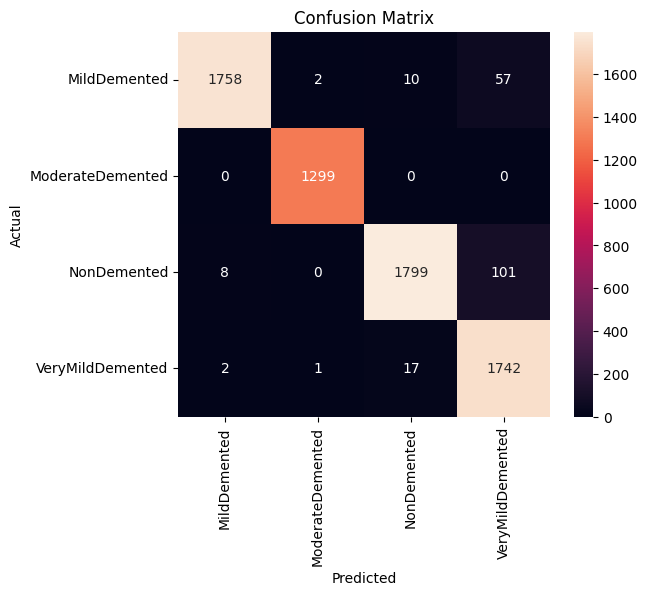

[train] batch=0 loss=0.0145 acc=1.0000
[train] batch=50 loss=0.0342 acc=1.0000
[train] batch=100 loss=0.0094 acc=1.0000
[train] batch=150 loss=0.1147 acc=0.9688
[train] batch=200 loss=0.0019 acc=1.0000
[train] batch=250 loss=0.0143 acc=1.0000
[train] batch=300 loss=0.0221 acc=1.0000
[train] batch=350 loss=0.0713 acc=0.9688
[train] batch=400 loss=0.0414 acc=0.9688
[train] batch=450 loss=0.0869 acc=0.9688
[train] batch=500 loss=0.0586 acc=0.9688
[train] batch=550 loss=0.0093 acc=1.0000
[train] batch=600 loss=0.0704 acc=0.9375
[train] batch=650 loss=0.0021 acc=1.0000
[train] batch=700 loss=0.0034 acc=1.0000
[train] batch=750 loss=0.1487 acc=0.9375
[train] batch=800 loss=0.1499 acc=0.9688


Validation: |          | 0/? [00:00<?, ?it/s]


📊 Validation accuracy (epoch end): 0.9628


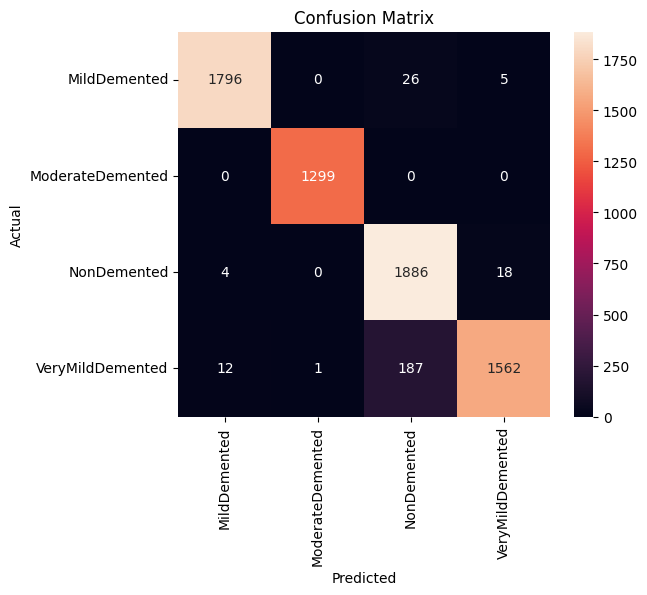

✅ Training finished


In [11]:
print("🧠 Starting training...")
trainer.fit(model, train_loader, val_loader)
print("✅ Training finished")


LOCAL_RANK: 0 - CUDA_VISIBLE_DEVICES: [0]


🔍 Running final validation using the best checkpoint (if available)...


Validation: |          | 0/? [00:00<?, ?it/s]


📊 Validation accuracy (epoch end): 0.9628


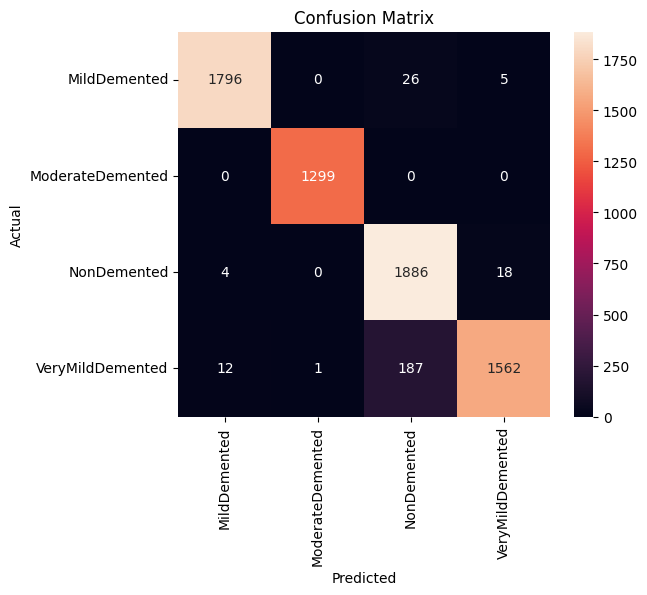

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━━━━┓
┃      Validate metric      ┃       DataLoader 0        ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━━━━┩
│          val_acc          │    0.9627721905708313     │
│         val_loss          │    0.10893866419792175    │
└───────────────────────────┴───────────────────────────┘

[{'val_loss': 0.10893866419792175, 'val_acc': 0.9627721905708313}]

In [12]:
print("🔍 Running final validation using the best checkpoint (if available)...")
trainer.validate(model, val_loader)


In [13]:
from PIL import Image

def predict_image(image_path, model_checkpoint_path=None):
    img = Image.open(image_path).convert('RGB')
    x = val_transform(img).unsqueeze(0)
    model_to_use = model
    if model_checkpoint_path:
        model_to_use = AlzheimerViT.load_from_checkpoint(model_checkpoint_path, map_location=device)
        model_to_use.eval()
    model_to_use.to(device)
    with torch.no_grad():
        logits = model_to_use(x.to(device))
        probs = torch.nn.functional.softmax(logits, dim=1)
        pred = probs.argmax(dim=1).item()
    return classes[pred], probs[0][pred].item()

print("✅ Inference helper ready")


✅ Inference helper ready


In [14]:
# Example (uncomment and set path)
# test_image = "Data/Non Demented/example.jpg"
# pred_class, confidence = predict_image(test_image)
# print(f"Prediction: {pred_class} (confidence={confidence:.4f})")

print("Notebook ready ✅ — Run cells one by one in order.")


Notebook ready ✅ — Run cells one by one in order.


Seed set to 42


Loading new test data from: OriginalDataset...
✅ Found 6400 images in 4 classes:
['MildDemented', 'ModerateDemented', 'NonDemented', 'VeryMildDemented']

Loading model from checkpoint: /teamspace/studios/this_studio/lightning_logs/version_0/checkpoints/alzheimer-vit-epoch=03-val_acc=0.9740.ckpt


💡 Tip: For seamless cloud uploads and versioning, try installing [litmodels](https://pypi.org/project/litmodels/) to enable LitModelCheckpoint, which syncs automatically with the Lightning model registry.
GPU available: True (cuda), used: True
TPU available: False, using: 0 TPU cores
HPU available: False, using: 0 HPUs
LOCAL_RANK: 0 - CUDA_VISIBLE_DEVICES: [0]


✅ 3-Channel model and weights loaded successfully.

🔬 Running validation on the 'OriginalDataset' data...


Validation: |          | 0/? [00:00<?, ?it/s]


     FINAL RESULTS ON NEW, UNSEEN TEST DATA (REAL)
🔥 FINAL ACCURACY (Hold-out Set): 99.08%

Classification Report:

                  precision    recall  f1-score   support

    MildDemented       0.99      1.00      0.99       896
ModerateDemented       1.00      1.00      1.00        64
     NonDemented       0.99      0.99      0.99      3200
VeryMildDemented       0.99      0.98      0.99      2240

        accuracy                           0.99      6400
       macro avg       0.99      0.99      0.99      6400
    weighted avg       0.99      0.99      0.99      6400


Confusion Matrix (True Labels vs Predicted Labels):



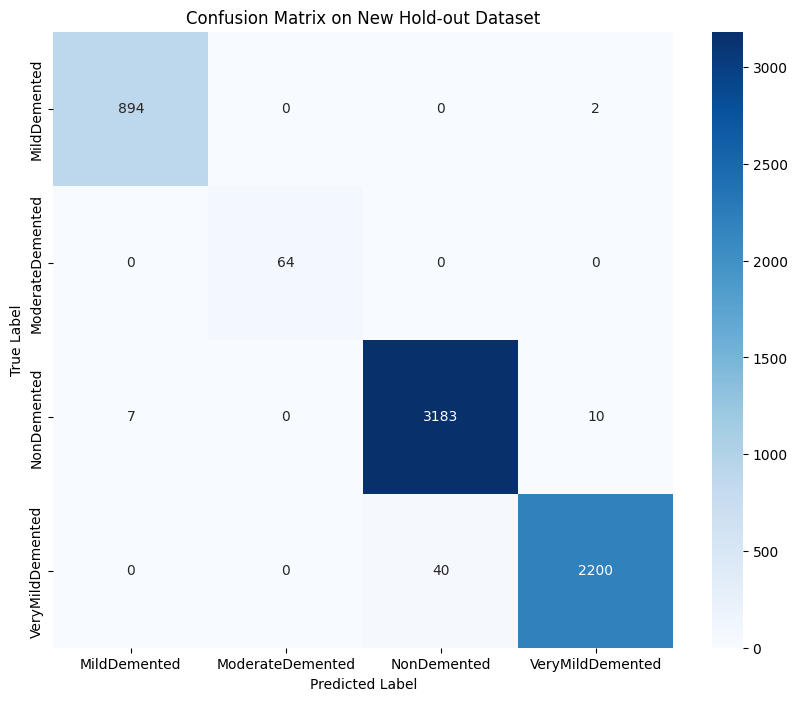

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━━━━┓
┃      Validate metric      ┃       DataLoader 0        ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━━━━┩
│          val_acc          │    0.9907812476158142     │
│         val_loss          │   0.027968797832727432    │
└───────────────────────────┴───────────────────────────┘

✅ Validation complete.


In [10]:
import os
import torch
import numpy as np
import seaborn as sns
import matplotlib.pyplot as plt
from sklearn.metrics import accuracy_score, confusion_matrix, classification_report
from torchvision import datasets, transforms
from torch.utils.data import DataLoader
import torch.nn.functional as F
import pytorch_lightning as pl
import timm

# ----------------------------------------------------------------------
# 1. ORIGINAL 3-CHANNEL MODEL DEFINITION
# (This MUST match the class structure your checkpoint was saved with)
# ----------------------------------------------------------------------
class AlzheimerViT(pl.LightningModule):
    # Pass classes to __init__ for plotting
    def __init__(self, num_classes, lr=1e-4, classes_list=None):
        super().__init__()
        self.save_hyperparameters()
        self.model = timm.create_model("vit_base_patch16_224", pretrained=False, num_classes=num_classes)
        self.lr = lr
        self.class_names = classes_list if classes_list is not None else [str(i) for i in range(num_classes)]

        # Use test_step logic for validation
        self.test_preds = []
        self.test_labels = []

    def forward(self, x):
        return self.model(x)

    # We need a validation step for trainer.validate() to use
    def validation_step(self, batch, batch_idx):
        images, labels = batch
        outputs = self(images)
        loss = F.cross_entropy(outputs, labels)
        preds = outputs.argmax(dim=1)
        
        # store preds and labels
        self.test_preds.append(preds.detach().cpu())
        self.test_labels.append(labels.detach().cpu())
        
        self.log('val_loss', loss, prog_bar=True)
        self.log('val_acc', (preds == labels).float().mean(), prog_bar=True)
        return loss

    # This will run at the end of trainer.validate()
    def on_validation_epoch_end(self):
        if not self.test_preds:
            print("\nNo validation predictions found.")
            return

        preds = torch.cat(self.test_preds, dim=0).numpy()
        labels = torch.cat(self.test_labels, dim=0).numpy()
        self.test_preds.clear()
        self.test_labels.clear()

        # --- This is where the metrics are calculated ---
        print("\n" + "="*60)
        print("     FINAL RESULTS ON NEW, UNSEEN TEST DATA (REAL)")
        print("="*60)
        
        # 1. Accuracy
        test_accuracy = accuracy_score(labels, preds)
        print(f"🔥 FINAL ACCURACY (Hold-out Set): {test_accuracy*100:.2f}%\n")

        # 2. Classification Report
        print("Classification Report:\n")
        report = classification_report(labels, preds, target_names=self.class_names, zero_division=0)
        print(report)

        # 3. Confusion Matrix
        print("\nConfusion Matrix (True Labels vs Predicted Labels):\n")
        cm = confusion_matrix(labels, preds)
        plt.figure(figsize=(10, 8))
        sns.heatmap(cm, annot=True, fmt='d', cmap='Blues', 
                    xticklabels=self.class_names, yticklabels=self.class_names)
        plt.xlabel('Predicted Label')
        plt.ylabel('True Label')
        plt.title('Confusion Matrix on New Hold-out Dataset')
        plt.savefig('confusion_matrix_OriginalDataset_test.png') # Save the figure
        plt.show() # Display the figure in the notebook
        print("="*60)

    # Required methods, even if not used for validation
    def training_step(self, batch, batch_idx):
        pass
        
    def configure_optimizers(self):
        return torch.optim.AdamW(self.parameters(), lr=self.lr)

# -------------------------------------------------------------
# STEP 2: CONFIGURATION
# -------------------------------------------------------------
# ⚠️ --- THIS IS THE ONLY CHANGE --- ⚠️
NEW_TEST_DATA_ROOT = "OriginalDataset" 

CHECKPOINT_PATH = '/teamspace/studios/this_studio/lightning_logs/version_0/checkpoints/alzheimer-vit-epoch=03-val_acc=0.9740.ckpt'
BATCH_SIZE = 32
IMG_SIZE = 224
NUM_WORKERS = 4
device = "cuda" if torch.cuda.is_available() else "cpu"
pl.seed_everything(42)

# Use the same transforms as your original validation set
test_transform = transforms.Compose([
    transforms.Resize((IMG_SIZE, IMG_SIZE)),
    transforms.ToTensor(),
    transforms.Normalize(mean=[0.485, 0.456, 0.406], std=[0.229, 0.224, 0.225])
])

# -------------------------------------------------------------
# STEP 3: DATA LOADING (Using ImageFolder)
# -------------------------------------------------------------
print(f"Loading new test data from: {NEW_TEST_DATA_ROOT}...")

# Use the simple datasets.ImageFolder
# This will automatically find the class folders
test_dataset = datasets.ImageFolder(
    root=NEW_TEST_DATA_ROOT,
    transform=test_transform
)

# Get the class names *found* by ImageFolder
classes_found = test_dataset.classes
num_classes = len(classes_found)

print(f"✅ Found {len(test_dataset)} images in {num_classes} classes:")
print(classes_found)

# Create the DataLoader
test_loader = DataLoader(
    test_dataset, 
    batch_size=BATCH_SIZE, 
    shuffle=False,
    num_workers=NUM_WORKERS,
    pin_memory=True
)

# -------------------------------------------------------------
# STEP 4: MODEL LOADING & VALIDATION
# -------------------------------------------------------------
print(f"\nLoading model from checkpoint: {CHECKPOINT_PATH}")

if not os.path.exists(CHECKPOINT_PATH):
    print(f"🚨 ERROR: Checkpoint file not found at {CHECKPOINT_PATH}")
    print("Please update the CHECKPOINT_PATH variable to the correct file path.")
else:
    # Load the model directly from the checkpoint
    # We pass the class names so the confusion matrix prints correctly
    model = AlzheimerViT.load_from_checkpoint(
        CHECKPOINT_PATH,
        map_location=device,
        num_classes=num_classes, # from the loaded dataset
        classes_list=classes_found # from the loaded dataset
    )
    
    print("✅ 3-Channel model and weights loaded successfully.")
    
    # Create a Trainer to run the validation loop
    trainer = pl.Trainer(
        accelerator='auto',
        devices=1 if torch.cuda.is_available() else None,
        logger=False # No need to log validation
    )

    print(f"\n🔬 Running validation on the '{NEW_TEST_DATA_ROOT}' data...")
    # Run the validation loop
    trainer.validate(model, test_loader)
    print("✅ Validation complete.")

Seed set to 42


Loading new test data from: Data...
✅ Found 86437 images in 4 classes:
['Mild Dementia', 'Moderate Dementia', 'Non Demented', 'Very mild Dementia']

Loading model from checkpoint: /teamspace/studios/this_studio/lightning_logs/version_0/checkpoints/alzheimer-vit-epoch=03-val_acc=0.9740.ckpt


💡 Tip: For seamless cloud uploads and versioning, try installing [litmodels](https://pypi.org/project/litmodels/) to enable LitModelCheckpoint, which syncs automatically with the Lightning model registry.
GPU available: True (cuda), used: True
TPU available: False, using: 0 TPU cores
HPU available: False, using: 0 HPUs
LOCAL_RANK: 0 - CUDA_VISIBLE_DEVICES: [0]


✅ 3-Channel model and weights loaded successfully.

🔬 Running validation on the new data...


Validation: |          | 0/? [00:00<?, ?it/s]


     FINAL RESULTS ON NEW, UNSEEN TEST DATA (REAL)
🔥 FINAL ACCURACY (Hold-out Set): 15.42%

Classification Report:

                    precision    recall  f1-score   support

     Mild Dementia       0.10      0.23      0.14      5002
 Moderate Dementia       0.00      0.00      0.00       488
      Non Demented       0.97      0.01      0.01     67222
Very mild Dementia       0.16      0.86      0.26     13725

          accuracy                           0.15     86437
         macro avg       0.31      0.27      0.11     86437
      weighted avg       0.78      0.15      0.06     86437


Confusion Matrix (True Labels vs Predicted Labels):



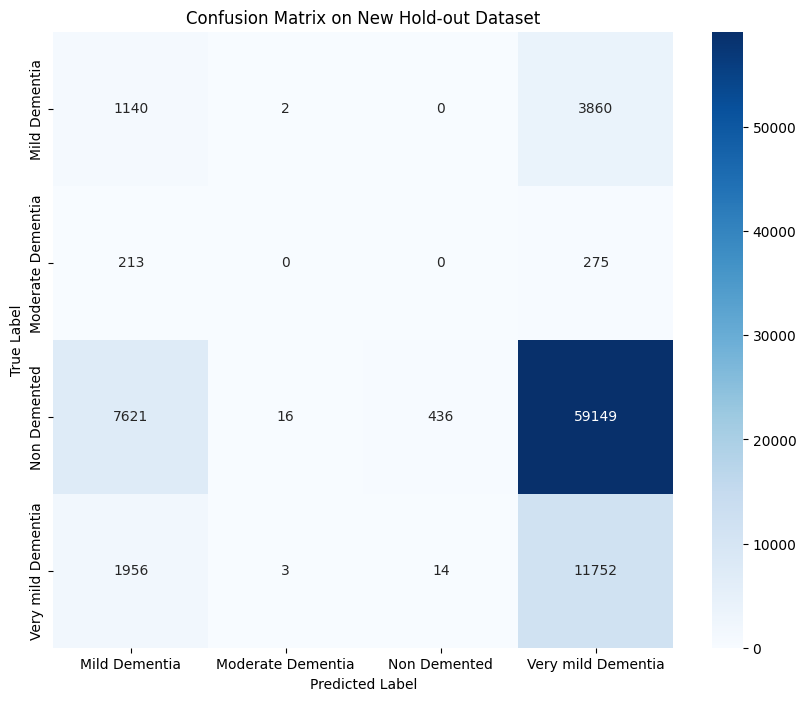

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━━━━┓
┃      Validate metric      ┃       DataLoader 0        ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━━━━┩
│          val_acc          │    0.1541932225227356     │
│         val_loss          │    4.9122748374938965     │
└───────────────────────────┴───────────────────────────┘

✅ Validation complete.


In [11]:
import os
import torch
import numpy as np
import seaborn as sns
import matplotlib.pyplot as plt
from sklearn.metrics import accuracy_score, confusion_matrix, classification_report
from torchvision import datasets, transforms
from torch.utils.data import DataLoader
import torch.nn.functional as F
import pytorch_lightning as pl
import timm

# ----------------------------------------------------------------------
# 1. ORIGINAL 3-CHANNEL MODEL DEFINITION
# (This MUST match the class structure your checkpoint was saved with)
# ----------------------------------------------------------------------
class AlzheimerViT(pl.LightningModule):
    # Pass classes to __init__ for plotting
    def __init__(self, num_classes, lr=1e-4, classes_list=None):
        super().__init__()
        self.save_hyperparameters()
        self.model = timm.create_model("vit_base_patch16_224", pretrained=False, num_classes=num_classes)
        self.lr = lr
        self.class_names = classes_list if classes_list is not None else [str(i) for i in range(num_classes)]

        # Use test_step logic for validation
        self.test_preds = []
        self.test_labels = []

    def forward(self, x):
        return self.model(x)

    # We need a validation step for trainer.validate() to use
    def validation_step(self, batch, batch_idx):
        images, labels = batch
        outputs = self(images)
        loss = F.cross_entropy(outputs, labels)
        preds = outputs.argmax(dim=1)
        
        # store preds and labels
        self.test_preds.append(preds.detach().cpu())
        self.test_labels.append(labels.detach().cpu())
        
        self.log('val_loss', loss, prog_bar=True)
        self.log('val_acc', (preds == labels).float().mean(), prog_bar=True)
        return loss

    # This will run at the end of trainer.validate()
    def on_validation_epoch_end(self):
        if not self.test_preds:
            print("\nNo validation predictions found.")
            return

        preds = torch.cat(self.test_preds, dim=0).numpy()
        labels = torch.cat(self.test_labels, dim=0).numpy()
        self.test_preds.clear()
        self.test_labels.clear()

        # --- This is where the metrics are calculated ---
        print("\n" + "="*60)
        print("     FINAL RESULTS ON NEW, UNSEEN TEST DATA (REAL)")
        print("="*60)
        
        # 1. Accuracy
        test_accuracy = accuracy_score(labels, preds)
        print(f"🔥 FINAL ACCURACY (Hold-out Set): {test_accuracy*100:.2f}%\n")

        # 2. Classification Report
        print("Classification Report:\n")
        report = classification_report(labels, preds, target_names=self.class_names, zero_division=0)
        print(report)

        # 3. Confusion Matrix
        print("\nConfusion Matrix (True Labels vs Predicted Labels):\n")
        cm = confusion_matrix(labels, preds)
        plt.figure(figsize=(10, 8))
        sns.heatmap(cm, annot=True, fmt='d', cmap='Blues', 
                    xticklabels=self.class_names, yticklabels=self.class_names)
        plt.xlabel('Predicted Label')
        plt.ylabel('True Label')
        plt.title('Confusion Matrix on New Hold-out Dataset')
        plt.savefig('confusion_matrix_NEW_DATA_test.png')
        plt.show()
        print("="*60)

    # Required methods, even if not used for validation
    def training_step(self, batch, batch_idx):
        pass
        
    def configure_optimizers(self):
        return torch.optim.AdamW(self.parameters(), lr=self.lr)

# -------------------------------------------------------------
# STEP 2: CONFIGURATION
# -------------------------------------------------------------
NEW_TEST_DATA_ROOT = "Data"
CHECKPOINT_PATH = '/teamspace/studios/this_studio/lightning_logs/version_0/checkpoints/alzheimer-vit-epoch=03-val_acc=0.9740.ckpt'
BATCH_SIZE = 32
IMG_SIZE = 224
NUM_WORKERS = 4
device = "cuda" if torch.cuda.is_available() else "cpu"
pl.seed_everything(42)

# Use the same transforms as your original validation set
test_transform = transforms.Compose([
    transforms.Resize((IMG_SIZE, IMG_SIZE)),
    transforms.ToTensor(),
    transforms.Normalize(mean=[0.485, 0.456, 0.406], std=[0.229, 0.224, 0.225])
])

# -------------------------------------------------------------
# STEP 3: DATA LOADING (Using ImageFolder)
# -------------------------------------------------------------
print(f"Loading new test data from: {NEW_TEST_DATA_ROOT}...")

# Use the simple datasets.ImageFolder
# This will automatically find the class folders with spaces
test_dataset = datasets.ImageFolder(
    root=NEW_TEST_DATA_ROOT,
    transform=test_transform
)

# Get the class names *found* by ImageFolder
classes_found = test_dataset.classes
num_classes = len(classes_found)

print(f"✅ Found {len(test_dataset)} images in {num_classes} classes:")
print(classes_found)

# Create the DataLoader
test_loader = DataLoader(
    test_dataset, 
    batch_size=BATCH_SIZE, 
    shuffle=False,
    num_workers=NUM_WORKERS,
    pin_memory=True
)

# -------------------------------------------------------------
# STEP 4: MODEL LOADING & VALIDATION
# -------------------------------------------------------------
print(f"\nLoading model from checkpoint: {CHECKPOINT_PATH}")

if not os.path.exists(CHECKPOINT_PATH):
    print(f"🚨 ERROR: Checkpoint file not found at {CHECKPOINT_PATH}")
    print("Please update the CHECKPOINT_PATH variable to the correct file path.")
else:
    # Load the model directly from the checkpoint
    # We pass the class names so the confusion matrix prints correctly
    model = AlzheimerViT.load_from_checkpoint(
        CHECKPOINT_PATH,
        map_location=device,
        num_classes=num_classes, # from the loaded dataset
        classes_list=classes_found # from the loaded dataset
    )
    
    print("✅ 3-Channel model and weights loaded successfully.")
    
    # Create a Trainer to run the validation loop
    trainer = pl.Trainer(
        accelerator='auto',
        devices=1 if torch.cuda.is_available() else None,
        logger=False # No need to log validation
    )

    print("\n🔬 Running validation on the new data...")
    # Run the validation loop
    trainer.validate(model, test_loader)
    print("✅ Validation complete.")

Seed set to 42


Loading new training data from: Data...
✅ Found 86437 images in 4 classes:
['Mild Dementia', 'Moderate Dementia', 'Non Demented', 'Very mild Dementia']
✅ Data split using stratification.
📦 New Train size: 69149 | New Val size: 17288

🔥 Loading model from checkpoint: /teamspace/studios/this_studio/lightning_logs/version_0/checkpoints/alzheimer-vit-epoch=03-val_acc=0.9740.ckpt


GPU available: True (cuda), used: True
TPU available: False, using: 0 TPU cores
HPU available: False, using: 0 HPUs
LOCAL_RANK: 0 - CUDA_VISIBLE_DEVICES: [0]

  | Name  | Type              | Params | Mode 
----------------------------------------------------
0 | model | VisionTransformer | 85.8 M | train
----------------------------------------------------
85.8 M    Trainable params
0         Non-trainable params
85.8 M    Total params
343.207   Total estimated model params size (MB)
276       Modules in train mode
0         Modules in eval mode


✅ 3-Channel model and weights loaded successfully.

🧠 Starting FINETUNING on new 'Data' folder...


Sanity Checking: |          | 0/? [00:00<?, ?it/s]


📊 Validation Results for Epoch 0
Accuracy: 12.50%

Classification Report:

                    precision    recall  f1-score   support

     Mild Dementia       0.00      0.00      0.00         2
 Moderate Dementia       0.00      0.00      0.00         1
      Non Demented       0.00      0.00      0.00        51
Very mild Dementia       0.14      0.80      0.23        10

          accuracy                           0.12        64
         macro avg       0.03      0.20      0.06        64
      weighted avg       0.02      0.12      0.04        64


Confusion Matrix:



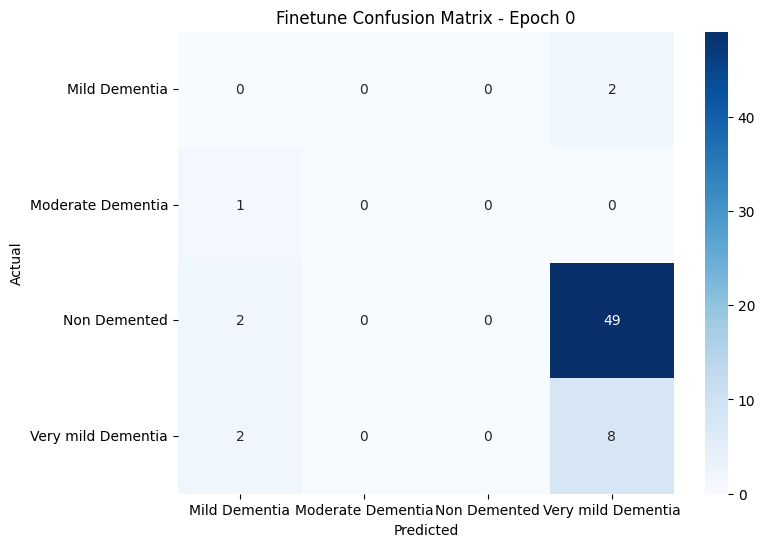

Training: |          | 0/? [00:00<?, ?it/s]

[train-ft] batch=0 loss=4.8692 acc=0.2188


[train-ft] batch=50 loss=0.5816 acc=0.7500
[train-ft] batch=100 loss=0.2954 acc=0.9062
[train-ft] batch=150 loss=0.3711 acc=0.8438
[train-ft] batch=200 loss=0.4314 acc=0.8438
[train-ft] batch=250 loss=0.2611 acc=0.9062
[train-ft] batch=300 loss=0.3417 acc=0.9062
[train-ft] batch=350 loss=0.3609 acc=0.8750
[train-ft] batch=400 loss=0.0910 acc=0.9688
[train-ft] batch=450 loss=0.3333 acc=0.8125
[train-ft] batch=500 loss=0.1828 acc=0.9375
[train-ft] batch=550 loss=0.3037 acc=0.8438
[train-ft] batch=600 loss=0.1297 acc=0.9375
[train-ft] batch=650 loss=0.2262 acc=0.9062
[train-ft] batch=700 loss=0.1030 acc=0.9688
[train-ft] batch=750 loss=0.5883 acc=0.8125
[train-ft] batch=800 loss=0.2182 acc=0.9062
[train-ft] batch=850 loss=0.0788 acc=0.9688
[train-ft] batch=900 loss=0.2121 acc=0.9062
[train-ft] batch=950 loss=0.1906 acc=0.9375
[train-ft] batch=1000 loss=0.0980 acc=0.9688
[train-ft] batch=1050 loss=0.0521 acc=0.9688
[train-ft] batch=1100 loss=0.0418 acc=1.0000
[train-ft] batch=1150 loss=0.0

Validation: |          | 0/? [00:00<?, ?it/s]


📊 Validation Results for Epoch 0
Accuracy: 98.70%

Classification Report:

                    precision    recall  f1-score   support

     Mild Dementia       1.00      0.88      0.93      1000
 Moderate Dementia       1.00      0.89      0.94        98
      Non Demented       0.99      1.00      0.99     13445
Very mild Dementia       0.95      0.99      0.97      2745

          accuracy                           0.99     17288
         macro avg       0.99      0.94      0.96     17288
      weighted avg       0.99      0.99      0.99     17288


Confusion Matrix:



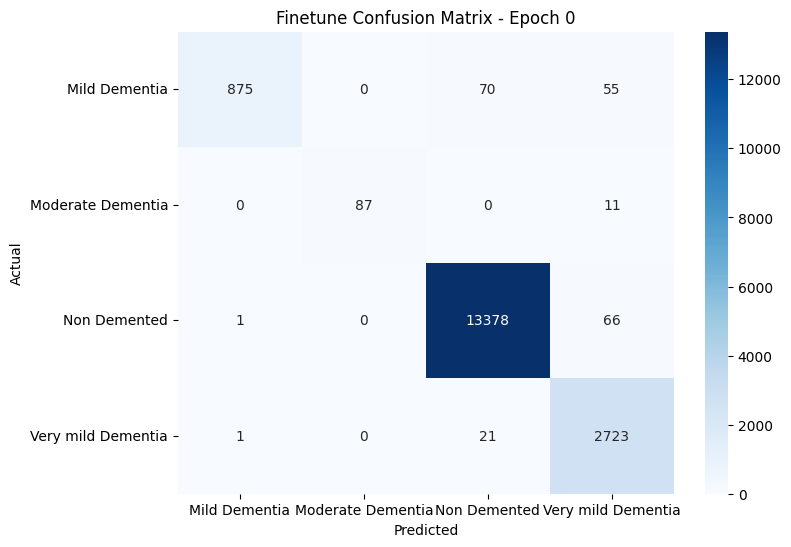

[train-ft] batch=0 loss=0.0013 acc=1.0000
[train-ft] batch=50 loss=0.0028 acc=1.0000
[train-ft] batch=100 loss=0.0195 acc=1.0000
[train-ft] batch=150 loss=0.0261 acc=1.0000
[train-ft] batch=200 loss=0.0068 acc=1.0000
[train-ft] batch=250 loss=0.0332 acc=0.9688
[train-ft] batch=300 loss=0.0100 acc=1.0000
[train-ft] batch=350 loss=0.0064 acc=1.0000
[train-ft] batch=400 loss=0.1467 acc=0.9688
[train-ft] batch=450 loss=0.0329 acc=0.9688
[train-ft] batch=500 loss=0.0044 acc=1.0000
[train-ft] batch=550 loss=0.0310 acc=1.0000
[train-ft] batch=600 loss=0.0425 acc=0.9688
[train-ft] batch=650 loss=0.0079 acc=1.0000
[train-ft] batch=700 loss=0.0022 acc=1.0000
[train-ft] batch=750 loss=0.1560 acc=0.9375
[train-ft] batch=800 loss=0.1247 acc=0.9375
[train-ft] batch=850 loss=0.0638 acc=0.9688
[train-ft] batch=900 loss=0.0032 acc=1.0000
[train-ft] batch=950 loss=0.0023 acc=1.0000
[train-ft] batch=1000 loss=0.0004 acc=1.0000
[train-ft] batch=1050 loss=0.0004 acc=1.0000
[train-ft] batch=1100 loss=0.0004

Validation: |          | 0/? [00:00<?, ?it/s]


📊 Validation Results for Epoch 1
Accuracy: 99.63%

Classification Report:

                    precision    recall  f1-score   support

     Mild Dementia       1.00      0.99      1.00      1000
 Moderate Dementia       1.00      0.96      0.98        98
      Non Demented       1.00      1.00      1.00     13445
Very mild Dementia       0.99      0.99      0.99      2745

          accuracy                           1.00     17288
         macro avg       1.00      0.99      0.99     17288
      weighted avg       1.00      1.00      1.00     17288


Confusion Matrix:



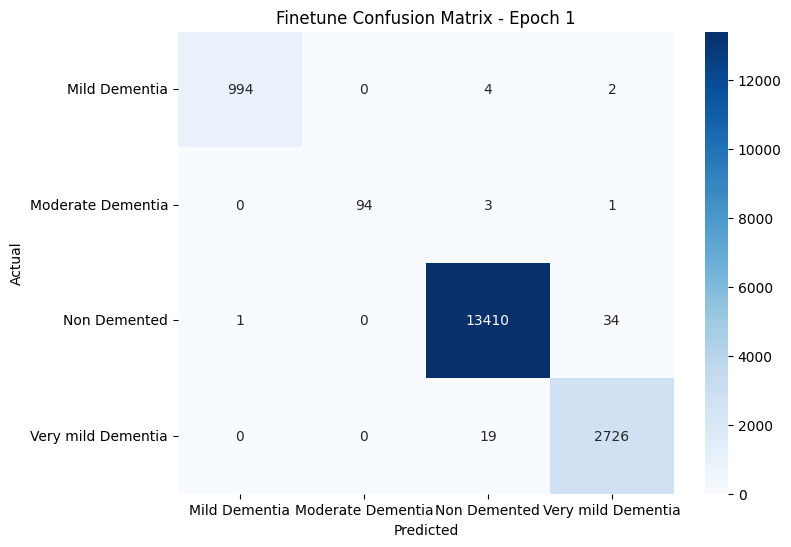

[train-ft] batch=0 loss=0.0002 acc=1.0000
[train-ft] batch=50 loss=0.0001 acc=1.0000
[train-ft] batch=100 loss=0.0002 acc=1.0000
[train-ft] batch=150 loss=0.0007 acc=1.0000
[train-ft] batch=200 loss=0.0001 acc=1.0000
[train-ft] batch=250 loss=0.0011 acc=1.0000
[train-ft] batch=300 loss=0.0005 acc=1.0000
[train-ft] batch=350 loss=0.0031 acc=1.0000
[train-ft] batch=400 loss=0.0006 acc=1.0000
[train-ft] batch=450 loss=0.0012 acc=1.0000
[train-ft] batch=500 loss=0.0000 acc=1.0000
[train-ft] batch=550 loss=0.0003 acc=1.0000
[train-ft] batch=600 loss=0.0009 acc=1.0000
[train-ft] batch=650 loss=0.0003 acc=1.0000
[train-ft] batch=700 loss=0.0006 acc=1.0000
[train-ft] batch=750 loss=0.0008 acc=1.0000
[train-ft] batch=800 loss=0.0038 acc=1.0000
[train-ft] batch=850 loss=0.0003 acc=1.0000
[train-ft] batch=900 loss=0.0028 acc=1.0000
[train-ft] batch=950 loss=0.0006 acc=1.0000
[train-ft] batch=1000 loss=0.0080 acc=1.0000
[train-ft] batch=1050 loss=0.0017 acc=1.0000
[train-ft] batch=1100 loss=0.0004

Validation: |          | 0/? [00:00<?, ?it/s]


📊 Validation Results for Epoch 2
Accuracy: 99.88%

Classification Report:

                    precision    recall  f1-score   support

     Mild Dementia       1.00      1.00      1.00      1000
 Moderate Dementia       1.00      0.99      0.99        98
      Non Demented       1.00      1.00      1.00     13445
Very mild Dementia       1.00      1.00      1.00      2745

          accuracy                           1.00     17288
         macro avg       1.00      1.00      1.00     17288
      weighted avg       1.00      1.00      1.00     17288


Confusion Matrix:



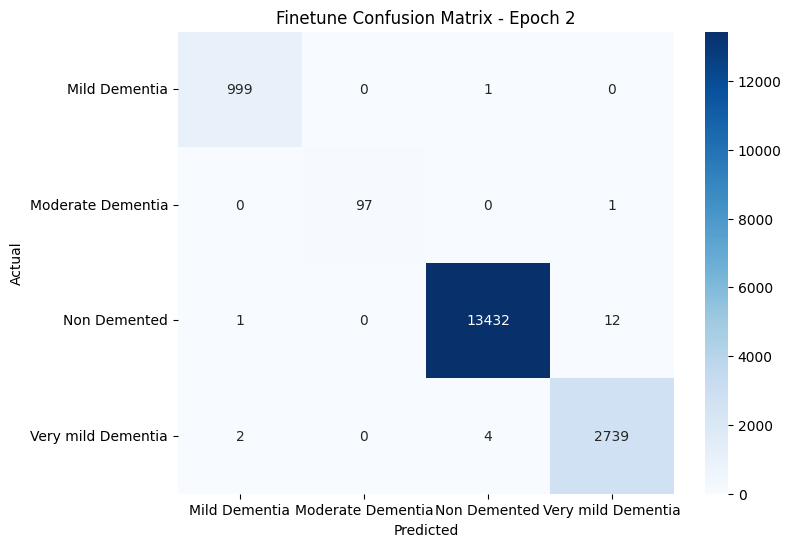

[train-ft] batch=0 loss=0.0000 acc=1.0000
[train-ft] batch=50 loss=0.0000 acc=1.0000
[train-ft] batch=100 loss=0.0001 acc=1.0000
[train-ft] batch=150 loss=0.0004 acc=1.0000
[train-ft] batch=200 loss=0.0008 acc=1.0000
[train-ft] batch=250 loss=0.0582 acc=0.9688
[train-ft] batch=300 loss=0.0481 acc=0.9688
[train-ft] batch=350 loss=0.0007 acc=1.0000
[train-ft] batch=400 loss=0.0001 acc=1.0000
[train-ft] batch=450 loss=0.0008 acc=1.0000
[train-ft] batch=500 loss=0.0002 acc=1.0000
[train-ft] batch=550 loss=0.0000 acc=1.0000
[train-ft] batch=600 loss=0.0001 acc=1.0000
[train-ft] batch=650 loss=0.0003 acc=1.0000
[train-ft] batch=700 loss=0.0006 acc=1.0000
[train-ft] batch=750 loss=0.0011 acc=1.0000
[train-ft] batch=800 loss=0.0017 acc=1.0000
[train-ft] batch=850 loss=0.0000 acc=1.0000
[train-ft] batch=900 loss=0.2396 acc=0.9688
[train-ft] batch=950 loss=0.0002 acc=1.0000
[train-ft] batch=1000 loss=0.0064 acc=1.0000
[train-ft] batch=1050 loss=0.0001 acc=1.0000
[train-ft] batch=1100 loss=0.0038

Validation: |          | 0/? [00:00<?, ?it/s]


📊 Validation Results for Epoch 3
Accuracy: 99.60%

Classification Report:

                    precision    recall  f1-score   support

     Mild Dementia       1.00      1.00      1.00      1000
 Moderate Dementia       1.00      1.00      1.00        98
      Non Demented       1.00      1.00      1.00     13445
Very mild Dementia       0.98      1.00      0.99      2745

          accuracy                           1.00     17288
         macro avg       0.99      1.00      1.00     17288
      weighted avg       1.00      1.00      1.00     17288


Confusion Matrix:



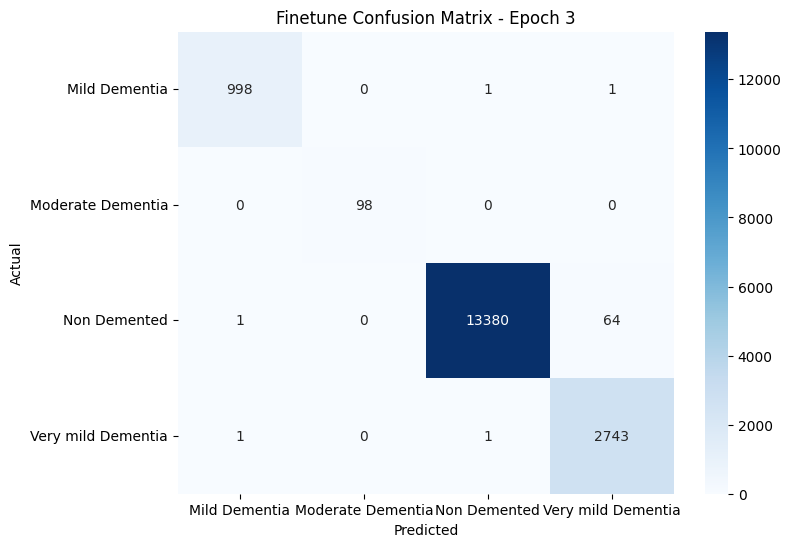

[train-ft] batch=0 loss=0.0003 acc=1.0000
[train-ft] batch=50 loss=0.0017 acc=1.0000
[train-ft] batch=100 loss=0.0174 acc=1.0000
[train-ft] batch=150 loss=0.0720 acc=0.9688
[train-ft] batch=200 loss=0.0000 acc=1.0000
[train-ft] batch=250 loss=0.0032 acc=1.0000
[train-ft] batch=300 loss=0.0002 acc=1.0000
[train-ft] batch=350 loss=0.0000 acc=1.0000
[train-ft] batch=400 loss=0.0003 acc=1.0000
[train-ft] batch=450 loss=0.0015 acc=1.0000
[train-ft] batch=500 loss=0.0000 acc=1.0000
[train-ft] batch=550 loss=0.0001 acc=1.0000
[train-ft] batch=600 loss=0.0000 acc=1.0000
[train-ft] batch=650 loss=0.0451 acc=0.9688
[train-ft] batch=700 loss=0.0002 acc=1.0000
[train-ft] batch=750 loss=0.0245 acc=0.9688
[train-ft] batch=800 loss=0.0206 acc=1.0000
[train-ft] batch=850 loss=0.0012 acc=1.0000
[train-ft] batch=900 loss=0.0005 acc=1.0000
[train-ft] batch=950 loss=0.0340 acc=0.9688
[train-ft] batch=1000 loss=0.0069 acc=1.0000
[train-ft] batch=1050 loss=0.0015 acc=1.0000
[train-ft] batch=1100 loss=0.0033

Validation: |          | 0/? [00:00<?, ?it/s]


📊 Validation Results for Epoch 4
Accuracy: 99.90%

Classification Report:

                    precision    recall  f1-score   support

     Mild Dementia       1.00      1.00      1.00      1000
 Moderate Dementia       1.00      1.00      1.00        98
      Non Demented       1.00      1.00      1.00     13445
Very mild Dementia       1.00      0.99      1.00      2745

          accuracy                           1.00     17288
         macro avg       1.00      1.00      1.00     17288
      weighted avg       1.00      1.00      1.00     17288


Confusion Matrix:



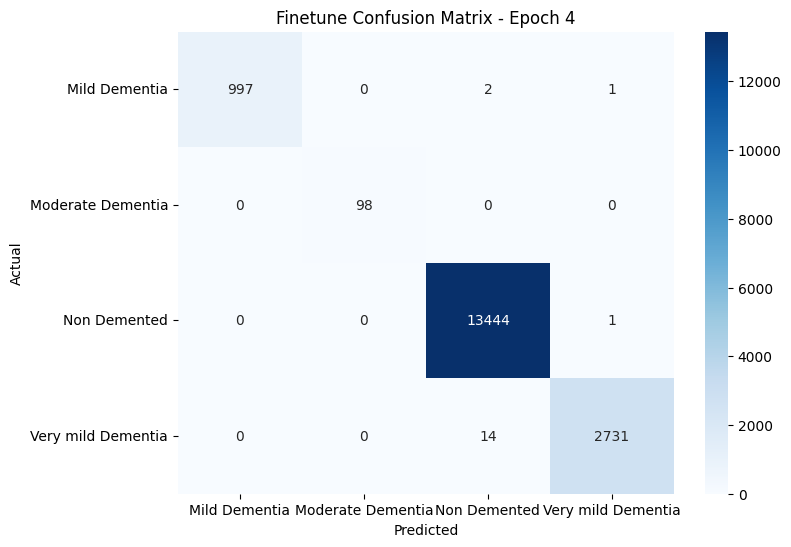

[train-ft] batch=0 loss=0.0001 acc=1.0000
[train-ft] batch=50 loss=0.0000 acc=1.0000
[train-ft] batch=100 loss=0.0001 acc=1.0000
[train-ft] batch=150 loss=0.0000 acc=1.0000
[train-ft] batch=200 loss=0.0000 acc=1.0000
[train-ft] batch=250 loss=0.0000 acc=1.0000
[train-ft] batch=300 loss=0.0000 acc=1.0000
[train-ft] batch=350 loss=0.0000 acc=1.0000
[train-ft] batch=400 loss=0.0001 acc=1.0000
[train-ft] batch=450 loss=0.0005 acc=1.0000
[train-ft] batch=500 loss=0.0503 acc=0.9688
[train-ft] batch=550 loss=0.0005 acc=1.0000
[train-ft] batch=600 loss=0.0009 acc=1.0000
[train-ft] batch=650 loss=0.0030 acc=1.0000
[train-ft] batch=700 loss=0.0001 acc=1.0000
[train-ft] batch=750 loss=0.0015 acc=1.0000
[train-ft] batch=800 loss=0.0001 acc=1.0000
[train-ft] batch=850 loss=0.0004 acc=1.0000
[train-ft] batch=900 loss=0.0000 acc=1.0000
[train-ft] batch=950 loss=0.0002 acc=1.0000
[train-ft] batch=1000 loss=0.0000 acc=1.0000
[train-ft] batch=1050 loss=0.0009 acc=1.0000
[train-ft] batch=1100 loss=0.0000

Validation: |          | 0/? [00:00<?, ?it/s]


📊 Validation Results for Epoch 5
Accuracy: 99.90%

Classification Report:

                    precision    recall  f1-score   support

     Mild Dementia       1.00      1.00      1.00      1000
 Moderate Dementia       0.98      1.00      0.99        98
      Non Demented       1.00      1.00      1.00     13445
Very mild Dementia       1.00      1.00      1.00      2745

          accuracy                           1.00     17288
         macro avg       0.99      1.00      1.00     17288
      weighted avg       1.00      1.00      1.00     17288


Confusion Matrix:



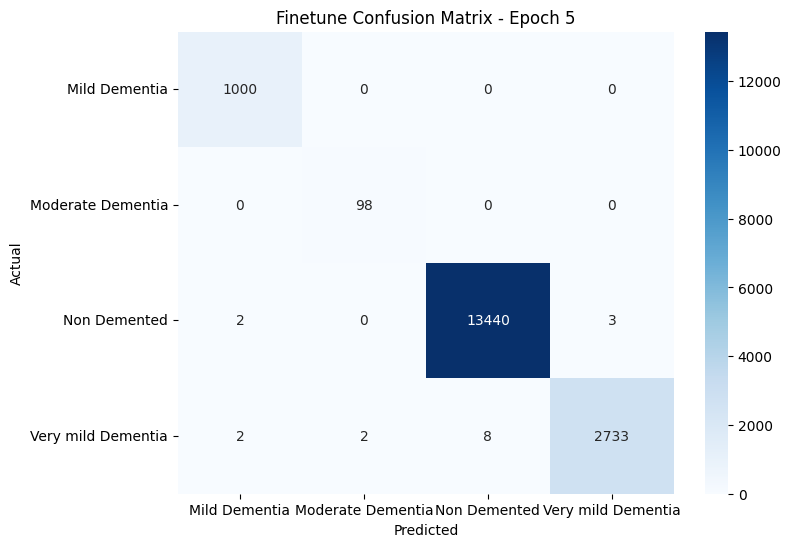

[train-ft] batch=0 loss=0.0000 acc=1.0000
[train-ft] batch=50 loss=0.0009 acc=1.0000
[train-ft] batch=100 loss=0.0001 acc=1.0000
[train-ft] batch=150 loss=0.0000 acc=1.0000
[train-ft] batch=200 loss=0.0000 acc=1.0000
[train-ft] batch=250 loss=0.0000 acc=1.0000
[train-ft] batch=300 loss=0.0000 acc=1.0000
[train-ft] batch=350 loss=0.0000 acc=1.0000
[train-ft] batch=400 loss=0.0000 acc=1.0000
[train-ft] batch=450 loss=0.0005 acc=1.0000
[train-ft] batch=500 loss=0.0000 acc=1.0000
[train-ft] batch=550 loss=0.0005 acc=1.0000
[train-ft] batch=600 loss=0.0001 acc=1.0000
[train-ft] batch=650 loss=0.0008 acc=1.0000
[train-ft] batch=700 loss=0.0000 acc=1.0000
[train-ft] batch=750 loss=0.0000 acc=1.0000
[train-ft] batch=800 loss=0.0004 acc=1.0000
[train-ft] batch=850 loss=0.0010 acc=1.0000
[train-ft] batch=900 loss=0.0000 acc=1.0000
[train-ft] batch=950 loss=0.0004 acc=1.0000
[train-ft] batch=1000 loss=0.0001 acc=1.0000
[train-ft] batch=1050 loss=0.0163 acc=1.0000
[train-ft] batch=1100 loss=0.0123

Validation: |          | 0/? [00:00<?, ?it/s]


📊 Validation Results for Epoch 6
Accuracy: 99.99%

Classification Report:

                    precision    recall  f1-score   support

     Mild Dementia       1.00      1.00      1.00      1000
 Moderate Dementia       1.00      1.00      1.00        98
      Non Demented       1.00      1.00      1.00     13445
Very mild Dementia       1.00      1.00      1.00      2745

          accuracy                           1.00     17288
         macro avg       1.00      1.00      1.00     17288
      weighted avg       1.00      1.00      1.00     17288


Confusion Matrix:



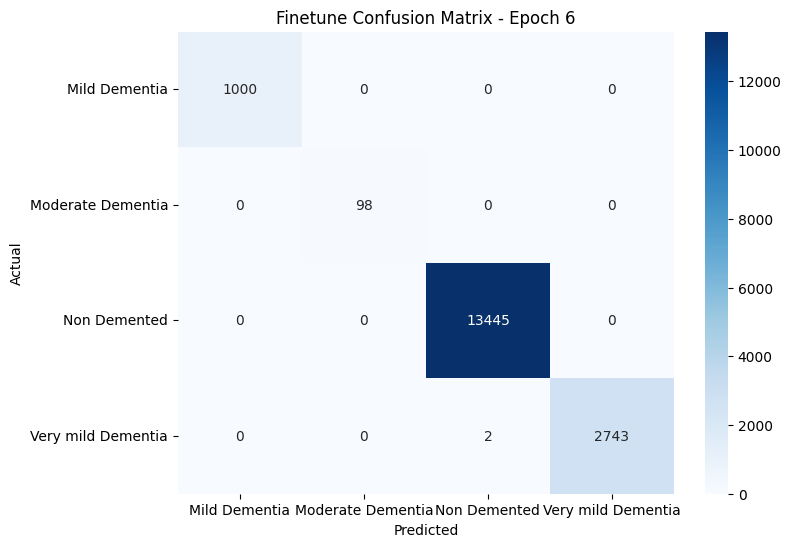

[train-ft] batch=0 loss=0.0000 acc=1.0000
[train-ft] batch=50 loss=0.0000 acc=1.0000
[train-ft] batch=100 loss=0.0000 acc=1.0000
[train-ft] batch=150 loss=0.0000 acc=1.0000
[train-ft] batch=200 loss=0.0000 acc=1.0000
[train-ft] batch=250 loss=0.0002 acc=1.0000
[train-ft] batch=300 loss=0.0000 acc=1.0000
[train-ft] batch=350 loss=0.0000 acc=1.0000
[train-ft] batch=400 loss=0.0000 acc=1.0000
[train-ft] batch=450 loss=0.0000 acc=1.0000
[train-ft] batch=500 loss=0.0000 acc=1.0000
[train-ft] batch=550 loss=0.0000 acc=1.0000
[train-ft] batch=600 loss=0.0000 acc=1.0000
[train-ft] batch=650 loss=0.0012 acc=1.0000
[train-ft] batch=700 loss=0.0025 acc=1.0000
[train-ft] batch=750 loss=0.0633 acc=0.9688
[train-ft] batch=800 loss=0.0631 acc=0.9688
[train-ft] batch=850 loss=0.0001 acc=1.0000
[train-ft] batch=900 loss=0.0000 acc=1.0000
[train-ft] batch=950 loss=0.0006 acc=1.0000
[train-ft] batch=1000 loss=0.0000 acc=1.0000
[train-ft] batch=1050 loss=0.0002 acc=1.0000
[train-ft] batch=1100 loss=0.0002

Validation: |          | 0/? [00:00<?, ?it/s]


📊 Validation Results for Epoch 7
Accuracy: 99.68%

Classification Report:

                    precision    recall  f1-score   support

     Mild Dementia       1.00      0.98      0.99      1000
 Moderate Dementia       1.00      1.00      1.00        98
      Non Demented       1.00      1.00      1.00     13445
Very mild Dementia       0.98      1.00      0.99      2745

          accuracy                           1.00     17288
         macro avg       1.00      0.99      1.00     17288
      weighted avg       1.00      1.00      1.00     17288


Confusion Matrix:



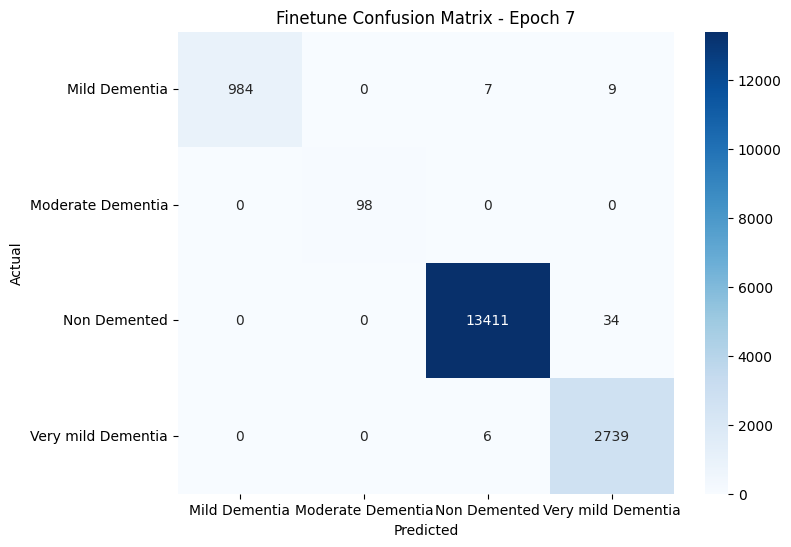

[train-ft] batch=0 loss=0.0010 acc=1.0000
[train-ft] batch=50 loss=0.0002 acc=1.0000
[train-ft] batch=100 loss=0.0000 acc=1.0000
[train-ft] batch=150 loss=0.0002 acc=1.0000
[train-ft] batch=200 loss=0.0001 acc=1.0000
[train-ft] batch=250 loss=0.0000 acc=1.0000
[train-ft] batch=300 loss=0.0008 acc=1.0000
[train-ft] batch=350 loss=0.0001 acc=1.0000
[train-ft] batch=400 loss=0.0002 acc=1.0000
[train-ft] batch=450 loss=0.0063 acc=1.0000
[train-ft] batch=500 loss=0.0019 acc=1.0000
[train-ft] batch=550 loss=0.0088 acc=1.0000
[train-ft] batch=600 loss=0.0019 acc=1.0000
[train-ft] batch=650 loss=0.0000 acc=1.0000
[train-ft] batch=700 loss=0.0000 acc=1.0000
[train-ft] batch=750 loss=0.0011 acc=1.0000
[train-ft] batch=800 loss=0.0001 acc=1.0000
[train-ft] batch=850 loss=0.0000 acc=1.0000
[train-ft] batch=900 loss=0.0000 acc=1.0000
[train-ft] batch=950 loss=0.0001 acc=1.0000
[train-ft] batch=1000 loss=0.0823 acc=0.9688
[train-ft] batch=1050 loss=0.0002 acc=1.0000
[train-ft] batch=1100 loss=0.0000

Validation: |          | 0/? [00:00<?, ?it/s]


📊 Validation Results for Epoch 8
Accuracy: 99.88%

Classification Report:

                    precision    recall  f1-score   support

     Mild Dementia       1.00      1.00      1.00      1000
 Moderate Dementia       1.00      1.00      1.00        98
      Non Demented       1.00      1.00      1.00     13445
Very mild Dementia       0.99      1.00      1.00      2745

          accuracy                           1.00     17288
         macro avg       1.00      1.00      1.00     17288
      weighted avg       1.00      1.00      1.00     17288


Confusion Matrix:



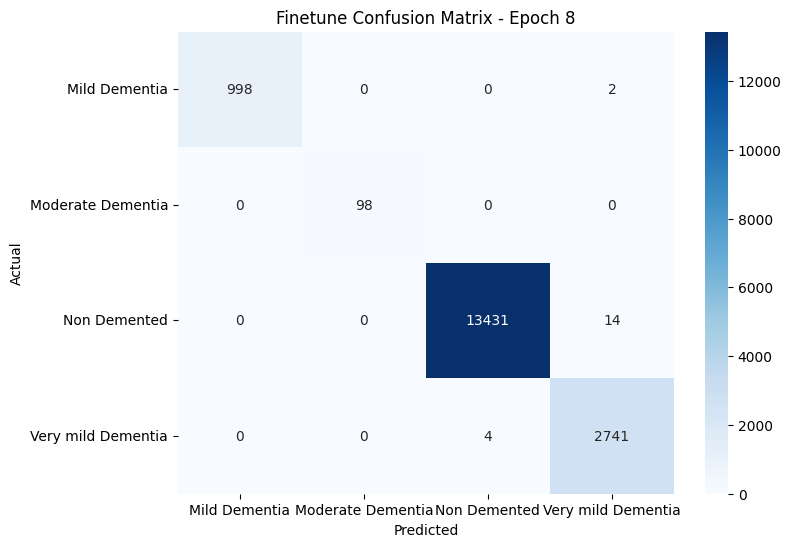

[train-ft] batch=0 loss=0.0001 acc=1.0000
[train-ft] batch=50 loss=0.0000 acc=1.0000
[train-ft] batch=100 loss=0.0000 acc=1.0000
[train-ft] batch=150 loss=0.0000 acc=1.0000
[train-ft] batch=200 loss=0.0004 acc=1.0000
[train-ft] batch=250 loss=0.0000 acc=1.0000
[train-ft] batch=300 loss=0.0000 acc=1.0000
[train-ft] batch=350 loss=0.0000 acc=1.0000
[train-ft] batch=400 loss=0.0000 acc=1.0000
[train-ft] batch=450 loss=0.0000 acc=1.0000
[train-ft] batch=500 loss=0.0001 acc=1.0000
[train-ft] batch=550 loss=0.0000 acc=1.0000
[train-ft] batch=600 loss=0.0000 acc=1.0000
[train-ft] batch=650 loss=0.0000 acc=1.0000
[train-ft] batch=700 loss=0.0000 acc=1.0000
[train-ft] batch=750 loss=0.0146 acc=1.0000
[train-ft] batch=800 loss=0.0000 acc=1.0000
[train-ft] batch=850 loss=0.0000 acc=1.0000
[train-ft] batch=900 loss=0.0693 acc=0.9688
[train-ft] batch=950 loss=0.0004 acc=1.0000
[train-ft] batch=1000 loss=0.0000 acc=1.0000
[train-ft] batch=1050 loss=0.0067 acc=1.0000
[train-ft] batch=1100 loss=0.0000

Validation: |          | 0/? [00:00<?, ?it/s]


📊 Validation Results for Epoch 9
Accuracy: 99.99%

Classification Report:

                    precision    recall  f1-score   support

     Mild Dementia       1.00      1.00      1.00      1000
 Moderate Dementia       1.00      1.00      1.00        98
      Non Demented       1.00      1.00      1.00     13445
Very mild Dementia       1.00      1.00      1.00      2745

          accuracy                           1.00     17288
         macro avg       1.00      1.00      1.00     17288
      weighted avg       1.00      1.00      1.00     17288


Confusion Matrix:



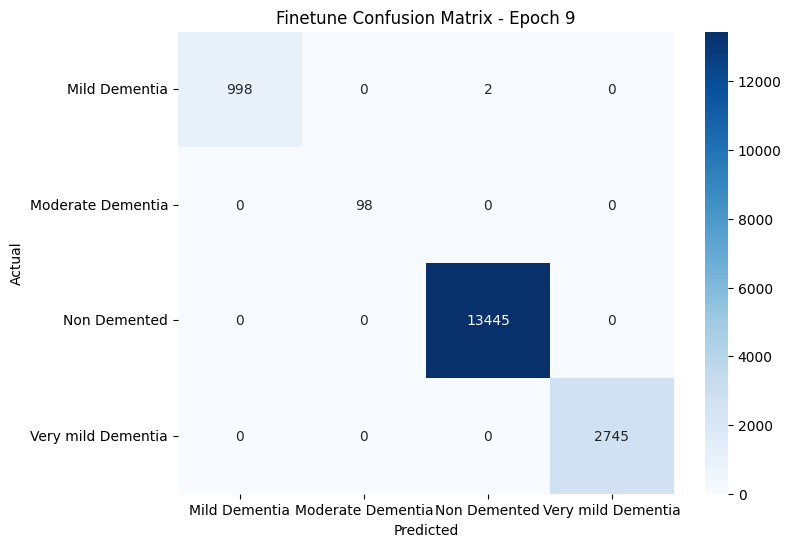

[train-ft] batch=0 loss=0.0000 acc=1.0000
[train-ft] batch=50 loss=0.0000 acc=1.0000
[train-ft] batch=100 loss=0.0000 acc=1.0000
[train-ft] batch=150 loss=0.0001 acc=1.0000
[train-ft] batch=200 loss=0.0001 acc=1.0000
[train-ft] batch=250 loss=0.0136 acc=1.0000
[train-ft] batch=300 loss=0.0003 acc=1.0000
[train-ft] batch=350 loss=0.0041 acc=1.0000
[train-ft] batch=400 loss=0.0827 acc=0.9688
[train-ft] batch=450 loss=0.0014 acc=1.0000
[train-ft] batch=500 loss=0.0002 acc=1.0000
[train-ft] batch=550 loss=0.0027 acc=1.0000
[train-ft] batch=600 loss=0.0001 acc=1.0000
[train-ft] batch=650 loss=0.0000 acc=1.0000
[train-ft] batch=700 loss=0.0002 acc=1.0000
[train-ft] batch=750 loss=0.0000 acc=1.0000
[train-ft] batch=800 loss=0.0000 acc=1.0000
[train-ft] batch=850 loss=0.0000 acc=1.0000
[train-ft] batch=900 loss=0.0000 acc=1.0000
[train-ft] batch=950 loss=0.0000 acc=1.0000
[train-ft] batch=1000 loss=0.0000 acc=1.0000
[train-ft] batch=1050 loss=0.0000 acc=1.0000
[train-ft] batch=1100 loss=0.0000

Validation: |          | 0/? [00:00<?, ?it/s]


📊 Validation Results for Epoch 10
Accuracy: 99.97%

Classification Report:

                    precision    recall  f1-score   support

     Mild Dementia       1.00      1.00      1.00      1000
 Moderate Dementia       1.00      1.00      1.00        98
      Non Demented       1.00      1.00      1.00     13445
Very mild Dementia       1.00      1.00      1.00      2745

          accuracy                           1.00     17288
         macro avg       1.00      1.00      1.00     17288
      weighted avg       1.00      1.00      1.00     17288


Confusion Matrix:



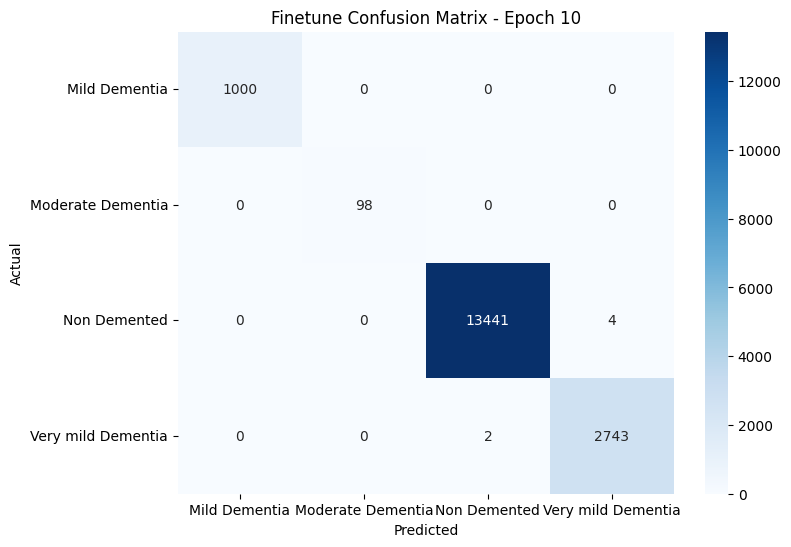

✅ Finetuning finished.


In [14]:
import os
import torch
import numpy as np
import seaborn as sns
import matplotlib.pyplot as plt
from sklearn.metrics import accuracy_score, confusion_matrix, classification_report
# --- ⚠️ NEW IMPORT ---
from sklearn.model_selection import train_test_split 
from torchvision import datasets, transforms
from torch.utils.data import DataLoader, Subset # ⚠️ Added Subset
import torch.nn.functional as F
import pytorch_lightning as pl
from pytorch_lightning.callbacks import ModelCheckpoint, EarlyStopping
import timm

# ----------------------------------------------------------------------
# 1. ORIGINAL 3-CHANNEL MODEL DEFINITION
# ----------------------------------------------------------------------
class AlzheimerViT(pl.LightningModule):
    def __init__(self, num_classes, lr=1e-4, classes_list=None):
        super().__init__()
        self.save_hyperparameters()
        self.model = timm.create_model("vit_base_patch16_224", pretrained=True, num_classes=num_classes)
        self.lr = lr
        self.class_names = classes_list if classes_list is not None else [str(i) for i in range(num_classes)]

        self.val_preds = []
        self.val_labels = []

    def forward(self, x):
        return self.model(x)

    def training_step(self, batch, batch_idx):
        images, labels = batch
        outputs = self(images)
        loss = F.cross_entropy(outputs, labels)
        preds = outputs.argmax(dim=1)
        acc = (preds == labels).float().mean()

        if batch_idx % 50 == 0:
            print(f"[train-ft] batch={batch_idx} loss={loss.item():.4f} acc={acc.item():.4f}")

        self.log('train_loss', loss, prog_bar=False, on_step=True, on_epoch=True)
        self.log('train_acc', acc, prog_bar=False, on_step=True, on_epoch=True)
        return loss

    def validation_step(self, batch, batch_idx):
        images, labels = batch
        outputs = self(images)
        loss = F.cross_entropy(outputs, labels)
        preds = outputs.argmax(dim=1)
        
        self.val_preds.append(preds.detach().cpu())
        self.val_labels.append(labels.detach().cpu())
        
        self.log('val_loss', loss, prog_bar=True, on_step=False, on_epoch=True)
        self.log('val_acc', (preds == labels).float().mean(), prog_bar=True, on_step=False, on_epoch=True)
        return loss

    def on_validation_epoch_end(self):
        if not self.val_preds:
            print("\nSkipping validation epoch end, no preds.")
            return

        preds = torch.cat(self.val_preds, dim=0).numpy()
        labels = torch.cat(self.val_labels, dim=0).numpy()
        self.val_preds.clear()
        self.val_labels.clear()

        print("\n" + "="*60)
        print(f"📊 Validation Results for Epoch {self.current_epoch}")
        print("="*60)
        
        acc = accuracy_score(labels, preds)
        print(f"Accuracy: {acc*100:.2f}%\n")

        print("Classification Report:\n")
        # ⚠️ This line was already fixed to prevent the crash,
        # but the stratified split is the true solution.
        all_class_indices = list(range(len(self.class_names)))
        report = classification_report(
            labels, 
            preds, 
            target_names=self.class_names, 
            labels=all_class_indices,
            zero_division=0
        )
        print(report)

        print("\nConfusion Matrix:\n")
        cm = confusion_matrix(labels, preds)
        plt.figure(figsize=(8, 6))
        sns.heatmap(cm, annot=True, fmt='d', cmap='Blues',
                    xticklabels=self.class_names, yticklabels=self.class_names)
        plt.xlabel('Predicted')
        plt.ylabel('Actual')
        plt.title(f'Finetune Confusion Matrix - Epoch {self.current_epoch}')
        plt.show()
        print("="*60)
        
    def configure_optimizers(self):
        return torch.optim.AdamW(self.parameters(), lr=self.lr)

# -------------------------------------------------------------
# STEP 2: CONFIGURATION
# -------------------------------------------------------------
NEW_DATA_DIR = "Data" 
CHECKPOINT_PATH = '/teamspace/studios/this_studio/lightning_logs/version_0/checkpoints/alzheimer-vit-epoch=03-val_acc=0.9740.ckpt'
BATCH_SIZE = 32
IMG_SIZE = 224
NUM_WORKERS = 4
LR = 1e-5       
MAX_EPOCHS = 20 
SEED = 42
VAL_SPLIT_SIZE = 0.2 # 20% for validation

device = "cuda" if torch.cuda.is_available() else "cpu"
pl.seed_everything(SEED)

# Transforms
train_transform = transforms.Compose([
    transforms.Resize((IMG_SIZE, IMG_SIZE)),
    transforms.RandomHorizontalFlip(),
    transforms.ToTensor(),
    transforms.Normalize([0.485, 0.456, 0.406], [0.229, 0.224, 0.225])
])

val_transform = transforms.Compose([
    transforms.Resize((IMG_SIZE, IMG_SIZE)),
    transforms.ToTensor(),
    transforms.Normalize([0.485, 0.456, 0.406], [0.229, 0.224, 0.225])
])

# -------------------------------------------------------------
# STEP 3: DATA LOADING (Using Stratified Split)
# -------------------------------------------------------------
print(f"Loading new training data from: {NEW_DATA_DIR}...")

# Load the full dataset *once* with train transforms
full_dataset = datasets.ImageFolder(
    root=NEW_DATA_DIR,
    transform=train_transform
)

classes_found = full_dataset.classes
num_classes = len(classes_found)

print(f"✅ Found {len(full_dataset)} images in {num_classes} classes:")
print(classes_found)

# --- ⚠️ NEW STRATIFIED SPLIT LOGIC ---
# Get all labels and indices
all_labels = full_dataset.targets
all_indices = np.arange(len(all_labels))

# Perform the stratified split
train_indices, val_indices = train_test_split(
    all_indices,
    test_size=VAL_SPLIT_SIZE,
    stratify=all_labels,  # This ensures proportional splits!
    random_state=SEED
)

# Create the train dataset subset
train_dataset = Subset(full_dataset, train_indices)

# Create a *separate* dataset for validation with validation transforms
val_full_dataset = datasets.ImageFolder(root=NEW_DATA_DIR, transform=val_transform)
val_dataset = Subset(val_full_dataset, val_indices)

print("✅ Data split using stratification.")
# --- END OF NEW LOGIC ---

# DataLoaders
train_loader = DataLoader(train_dataset, batch_size=BATCH_SIZE, shuffle=True, num_workers=NUM_WORKERS, pin_memory=True)
val_loader = DataLoader(val_dataset, batch_size=BATCH_SIZE, shuffle=False, num_workers=NUM_WORKERS, pin_memory=True)

print(f"📦 New Train size: {len(train_dataset)} | New Val size: {len(val_dataset)}")

# -------------------------------------------------------------
# STEP 4: MODEL LOADING & FINETUNING
# -------------------------------------------------------------
print(f"\n🔥 Loading model from checkpoint: {CHECKPOINT_PATH}")

if not os.path.exists(CHECKPOINT_PATH):
    print(f"🚨 ERROR: Checkpoint file not found at {CHECKPOINT_PATH}")
    print("Please update the CHECKPOINT_PATH variable to the correct file path.")
else:
    # Load the model directly from the checkpoint
    model = AlzheimerViT.load_from_checkpoint(
        CHECKPOINT_PATH,
        map_location=device,
        num_classes=num_classes, 
        lr=LR, # Use the new finetuning LR
        classes_list=classes_found
    )
    
    print("✅ 3-Channel model and weights loaded successfully.")
    
    # Define NEW callbacks for the finetuning run
    finetune_checkpoint_cb = ModelCheckpoint(
        monitor='val_acc',
        mode='max',
        save_top_k=1,
        filename='alzheimer-vit-FINETUNE-{epoch:02d}-{val_acc:.4f}',
        dirpath='finetuned_checkpoints_Data' # Save to a new folder
    )
    finetune_earlystop_cb = EarlyStopping(monitor='val_acc', patience=4, mode='max')

    # Create a new Trainer for finetuning
    finetune_trainer = pl.Trainer(
        max_epochs=MAX_EPOCHS,
        accelerator='auto',
        devices=1 if torch.cuda.is_available() else None,
        callbacks=[finetune_checkpoint_cb, finetune_earlystop_cb],
        log_every_n_steps=10
    )

    print("\n🧠 Starting FINETUNING on new 'Data' folder...")
    # Start the new training run
    finetune_trainer.fit(model, train_loader, val_loader)
    print("✅ Finetuning finished.")

In [17]:
!pip install kagglehub
import kagglehub

# Download latest version
path = kagglehub.dataset_download("kushagrasharma133/oasis-alzheimer-dataset")

print("Path to dataset files:", path)

100%|██████████| 1.23G/1.23G [00:39<00:00, 33.9MB/s]

Extracting files...


Path to dataset files: /teamspace/studios/this_studio/.cache/kagglehub/datasets/kushagrasharma133/oasis-alzheimer-dataset/versions/1


Seed set to 42


Loading new test data from: test...
✅ Found 17289 images in 4 classes:
['Mild Dementia', 'Moderate Dementia', 'Non Demented', 'Very mild Dementia']

Loading model from checkpoint: /teamspace/studios/this_studio/lightning_logs/version_0/checkpoints/alzheimer-vit-epoch=03-val_acc=0.9740.ckpt


💡 Tip: For seamless cloud uploads and versioning, try installing [litmodels](https://pypi.org/project/litmodels/) to enable LitModelCheckpoint, which syncs automatically with the Lightning model registry.
GPU available: True (cuda), used: True
TPU available: False, using: 0 TPU cores
HPU available: False, using: 0 HPUs
LOCAL_RANK: 0 - CUDA_VISIBLE_DEVICES: [0]


✅ 3-Channel model and weights loaded successfully.

🔬 Running validation on the new data...


Validation: |          | 0/? [00:00<?, ?it/s]


     FINAL RESULTS ON NEW, UNSEEN TEST DATA (REAL)
🔥 FINAL ACCURACY (Hold-out Set): 15.35%

Classification Report:

                    precision    recall  f1-score   support

     Mild Dementia       0.09      0.20      0.13      1001
 Moderate Dementia       0.00      0.00      0.00        98
      Non Demented       0.98      0.01      0.01     13445
Very mild Dementia       0.16      0.86      0.27      2745

          accuracy                           0.15     17289
         macro avg       0.31      0.27      0.10     17289
      weighted avg       0.79      0.15      0.06     17289


Confusion Matrix (True Labels vs Predicted Labels):



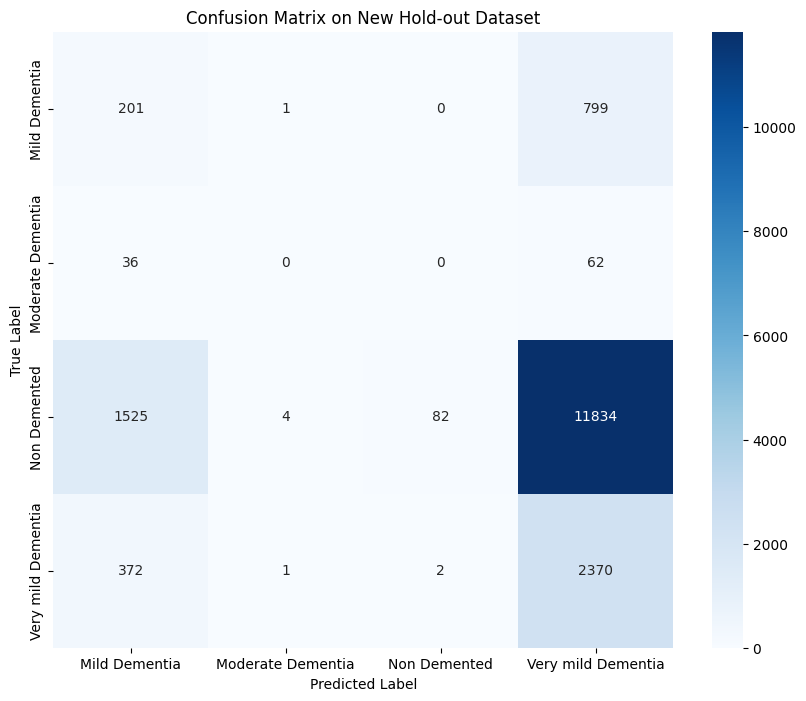

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━━━━┓
┃      Validate metric      ┃       DataLoader 0        ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━━━━┩
│          val_acc          │    0.15345017611980438    │
│         val_loss          │     4.918651580810547     │
└───────────────────────────┴───────────────────────────┘

✅ Validation complete.


In [19]:
import os
import torch
import numpy as np
import seaborn as sns
import matplotlib.pyplot as plt
from sklearn.metrics import accuracy_score, confusion_matrix, classification_report
from torchvision import datasets, transforms
from torch.utils.data import DataLoader
import torch.nn.functional as F
import pytorch_lightning as pl
import timm

# ----------------------------------------------------------------------
# 1. ORIGINAL 3-CHANNEL MODEL DEFINITION
# (This MUST match the class structure your checkpoint was saved with)
# ----------------------------------------------------------------------
class AlzheimerViT(pl.LightningModule):
    # Pass classes to __init__ for plotting
    def __init__(self, num_classes, lr=1e-4, classes_list=None):
        super().__init__()
        self.save_hyperparameters()
        self.model = timm.create_model("vit_base_patch16_224", pretrained=False, num_classes=num_classes)
        self.lr = lr
        self.class_names = classes_list if classes_list is not None else [str(i) for i in range(num_classes)]

        # Use test_step logic for validation
        self.test_preds = []
        self.test_labels = []

    def forward(self, x):
        return self.model(x)

    # We need a validation step for trainer.validate() to use
    def validation_step(self, batch, batch_idx):
        images, labels = batch
        outputs = self(images)
        loss = F.cross_entropy(outputs, labels)
        preds = outputs.argmax(dim=1)
        
        # store preds and labels
        self.test_preds.append(preds.detach().cpu())
        self.test_labels.append(labels.detach().cpu())
        
        self.log('val_loss', loss, prog_bar=True)
        self.log('val_acc', (preds == labels).float().mean(), prog_bar=True)
        return loss

    # This will run at the end of trainer.validate()
    def on_validation_epoch_end(self):
        if not self.test_preds:
            print("\nNo validation predictions found.")
            return

        preds = torch.cat(self.test_preds, dim=0).numpy()
        labels = torch.cat(self.test_labels, dim=0).numpy()
        self.test_preds.clear()
        self.test_labels.clear()

        # --- This is where the metrics are calculated ---
        print("\n" + "="*60)
        print("     FINAL RESULTS ON NEW, UNSEEN TEST DATA (REAL)")
        print("="*60)
        
        # 1. Accuracy
        test_accuracy = accuracy_score(labels, preds)
        print(f"🔥 FINAL ACCURACY (Hold-out Set): {test_accuracy*100:.2f}%\n")

        # 2. Classification Report
        print("Classification Report:\n")
        report = classification_report(labels, preds, target_names=self.class_names, zero_division=0)
        print(report)

        # 3. Confusion Matrix
        print("\nConfusion Matrix (True Labels vs Predicted Labels):\n")
        cm = confusion_matrix(labels, preds)
        plt.figure(figsize=(10, 8))
        sns.heatmap(cm, annot=True, fmt='d', cmap='Blues', 
                    xticklabels=self.class_names, yticklabels=self.class_names)
        plt.xlabel('Predicted Label')
        plt.ylabel('True Label')
        plt.title('Confusion Matrix on New Hold-out Dataset')
        plt.savefig('confusion_matrix_NEW_DATA_test.png')
        plt.show()
        print("="*60)

    # Required methods, even if not used for validation
    def training_step(self, batch, batch_idx):
        pass
        
    def configure_optimizers(self):
        return torch.optim.AdamW(self.parameters(), lr=self.lr)

# -------------------------------------------------------------
# STEP 2: CONFIGURATION
# -------------------------------------------------------------

# ⚠️ --- THIS IS THE FIX --- ⚠️
# Point to the 'train' folder directly
NEW_TEST_DATA_ROOT = "test"

CHECKPOINT_PATH = '/teamspace/studios/this_studio/lightning_logs/version_0/checkpoints/alzheimer-vit-epoch=03-val_acc=0.9740.ckpt'
BATCH_SIZE = 32
IMG_SIZE = 224
NUM_WORKERS = 4
device = "cuda" if torch.cuda.is_available() else "cpu"
pl.seed_everything(42)

# Use the same transforms as your original validation set
test_transform = transforms.Compose([
    transforms.Resize((IMG_SIZE, IMG_SIZE)),
    transforms.ToTensor(),
    transforms.Normalize(mean=[0.485, 0.456, 0.406], std=[0.229, 0.224, 0.225])
])

# -------------------------------------------------------------
# STEP 3: DATA LOADING (Using ImageFolder)
# -------------------------------------------------------------
print(f"Loading new test data from: {NEW_TEST_DATA_ROOT}...")

# Use the simple datasets.ImageFolder
test_dataset = datasets.ImageFolder(
    root=NEW_TEST_DATA_ROOT,
    transform=test_transform
)

# Get the class names *found* by ImageFolder
classes_found = test_dataset.classes
num_classes = len(classes_found)

print(f"✅ Found {len(test_dataset)} images in {num_classes} classes:")
print(classes_found)

# Create the DataLoader
test_loader = DataLoader(
    test_dataset, 
    batch_size=BATCH_SIZE, 
    shuffle=False,
    num_workers=NUM_WORKERS,
    pin_memory=True
)

# -------------------------------------------------------------
# STEP 4: MODEL LOADING & VALIDATION
# -------------------------------------------------------------
print(f"\nLoading model from checkpoint: {CHECKPOINT_PATH}")

if not os.path.exists(CHECKPOINT_PATH):
    print(f"🚨 ERROR: Checkpoint file not found at {CHECKPOINT_PATH}")
    print("Please update the CHECKPOINT_PATH variable to the correct file path.")
else:
    # Load the model directly from the checkpoint
    # We pass the class names so the confusion matrix prints correctly
    model = AlzheimerViT.load_from_checkpoint(
        CHECKPOINT_PATH,
        map_location=device,
        num_classes=num_classes, # from the loaded dataset
        classes_list=classes_found # from the loaded dataset
    )
    
    print("✅ 3-Channel model and weights loaded successfully.")
    
    # Create a Trainer to run the validation loop
    trainer = pl.Trainer(
        accelerator='auto',
        devices=1 if torch.cuda.is_available() else None,
        logger=False # No need to log validation
    )

    print("\n🔬 Running validation on the new data...")
    # Run the validation loop
    trainer.validate(model, test_loader)
    print("✅ Validation complete.")

Seed set to 42


Loading new training data from: train...
✅ Found 69148 training images in 4 classes:
['Mild Dementia', 'Moderate Dementia', 'Non Demented', 'Very mild Dementia']
✅ Training data split using stratification.
📦 New Train size: 55318 | New Val size: 13830

Loading new test data from: test...
✅ Found 17289 test images.

🔥 Loading model from checkpoint: /teamspace/studios/this_studio/lightning_logs/version_0/checkpoints/alzheimer-vit-epoch=03-val_acc=0.9740.ckpt


Using 16bit Automatic Mixed Precision (AMP)
GPU available: True (cuda), used: True
TPU available: False, using: 0 TPU cores
HPU available: False, using: 0 HPUs
/home/zeus/miniconda3/envs/cloudspace/lib/python3.12/site-packages/pytorch_lightning/callbacks/model_checkpoint.py:751: Checkpoint directory /teamspace/studios/this_studio/finetuned_checkpoints_Kaggle exists and is not empty.
LOCAL_RANK: 0 - CUDA_VISIBLE_DEVICES: [0]
/home/zeus/miniconda3/envs/cloudspace/lib/python3.12/site-packages/pytorch_lightning/utilities/model_summary/model_summary.py:231: Precision 16-mixed is not supported by the model summary.  Estimated model size in MB will not be accurate. Using 32 bits instead.

  | Name  | Type              | Params | Mode 
----------------------------------------------------
0 | model | VisionTransformer | 85.8 M | train
----------------------------------------------------
85.8 M    Trainable params
0         Non-trainable params
85.8 M    Total params
343.207   Total estimated mo

✅ 3-Channel model and weights loaded successfully.

🧠 Starting FINETUNING on 'train' folder...


Sanity Checking: |          | 0/? [00:00<?, ?it/s]


📊 FINETUNE VALIDATION RESULTS FOR EPOCH 0
Accuracy: 15.72%

Classification Report:

                    precision    recall  f1-score   support

     Mild Dementia       0.14      0.28      0.18        57
 Moderate Dementia       0.00      0.00      0.00         5
      Non Demented       1.00      0.01      0.01       796
Very mild Dementia       0.16      0.85      0.26       166

          accuracy                           0.16      1024
         macro avg       0.32      0.28      0.11      1024
      weighted avg       0.81      0.16      0.06      1024


Confusion Matrix:



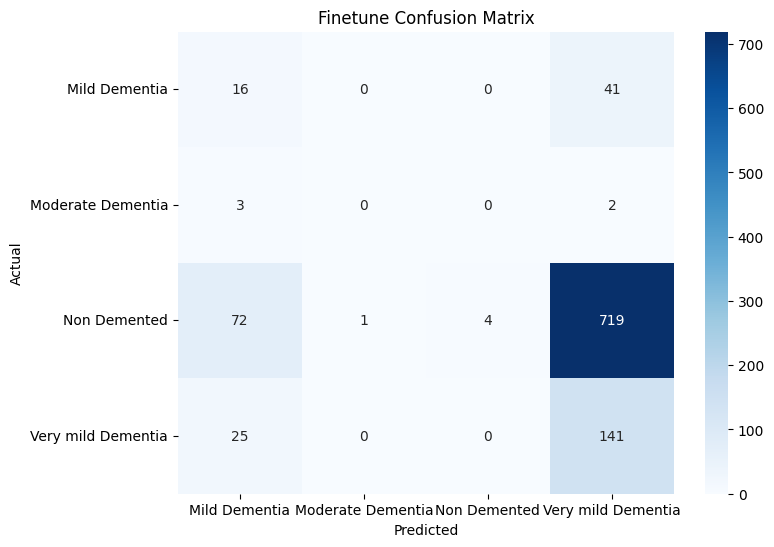

Training: |          | 0/? [00:00<?, ?it/s]

[train-ft] batch=0 loss=4.7592 acc=0.1641
[train-ft] batch=100 loss=0.4184 acc=0.8438


Validation: |          | 0/? [00:00<?, ?it/s]


📊 FINETUNE VALIDATION RESULTS FOR EPOCH 0
Accuracy: 82.64%

Classification Report:

                    precision    recall  f1-score   support

     Mild Dementia       0.61      0.37      0.46       800
 Moderate Dementia       0.00      0.00      0.00        78
      Non Demented       0.86      0.96      0.91     10756
Very mild Dementia       0.60      0.38      0.47      2196

          accuracy                           0.83     13830
         macro avg       0.52      0.43      0.46     13830
      weighted avg       0.80      0.83      0.81     13830


Confusion Matrix:



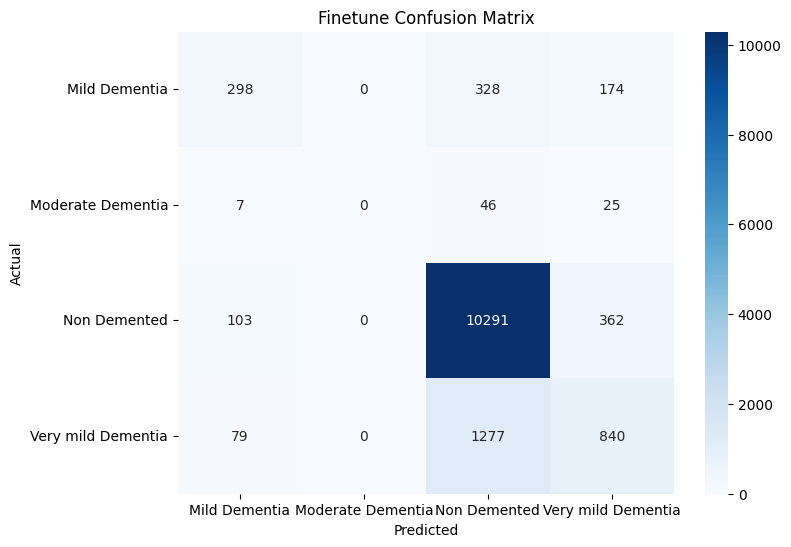

[train-ft] batch=0 loss=0.3648 acc=0.8359
[train-ft] batch=100 loss=0.2303 acc=0.9082


Validation: |          | 0/? [00:00<?, ?it/s]


📊 FINETUNE VALIDATION RESULTS FOR EPOCH 1
Accuracy: 90.72%

Classification Report:

                    precision    recall  f1-score   support

     Mild Dementia       0.84      0.67      0.74       800
 Moderate Dementia       0.88      0.19      0.32        78
      Non Demented       0.92      0.98      0.95     10756
Very mild Dementia       0.84      0.66      0.74      2196

          accuracy                           0.91     13830
         macro avg       0.87      0.63      0.69     13830
      weighted avg       0.90      0.91      0.90     13830


Confusion Matrix:



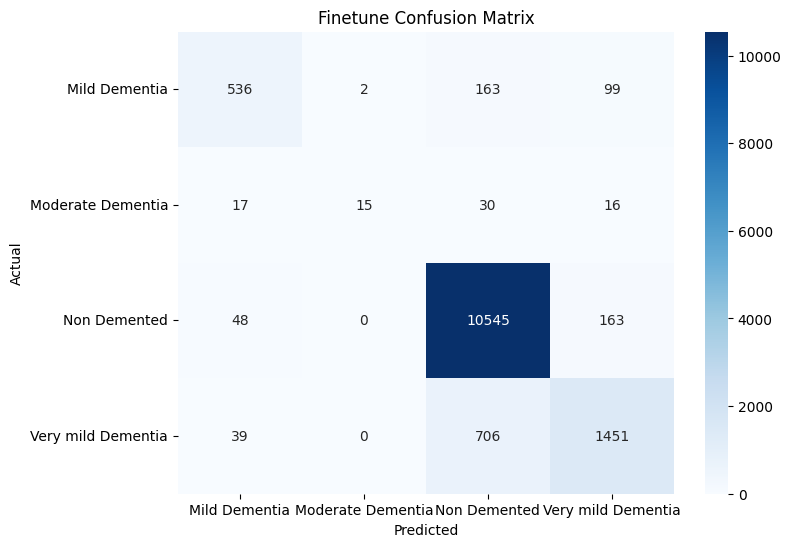

[train-ft] batch=0 loss=0.1949 acc=0.9258
[train-ft] batch=100 loss=0.0552 acc=0.9785


Validation: |          | 0/? [00:00<?, ?it/s]


📊 FINETUNE VALIDATION RESULTS FOR EPOCH 2
Accuracy: 96.39%

Classification Report:

                    precision    recall  f1-score   support

     Mild Dementia       0.92      0.94      0.93       800
 Moderate Dementia       0.82      0.85      0.84        78
      Non Demented       1.00      0.96      0.98     10756
Very mild Dementia       0.85      0.98      0.91      2196

          accuracy                           0.96     13830
         macro avg       0.90      0.93      0.91     13830
      weighted avg       0.97      0.96      0.96     13830


Confusion Matrix:



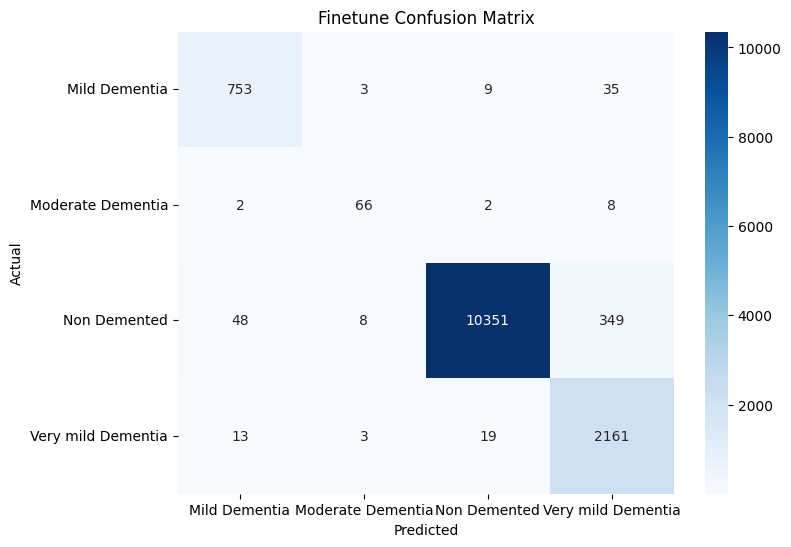

[train-ft] batch=0 loss=0.0598 acc=0.9824
[train-ft] batch=100 loss=0.0212 acc=0.9902


Validation: |          | 0/? [00:00<?, ?it/s]


📊 FINETUNE VALIDATION RESULTS FOR EPOCH 3
Accuracy: 98.97%

Classification Report:

                    precision    recall  f1-score   support

     Mild Dementia       0.98      0.98      0.98       800
 Moderate Dementia       0.99      0.94      0.96        78
      Non Demented       0.99      1.00      0.99     10756
Very mild Dementia       0.99      0.95      0.97      2196

          accuracy                           0.99     13830
         macro avg       0.99      0.97      0.98     13830
      weighted avg       0.99      0.99      0.99     13830


Confusion Matrix:



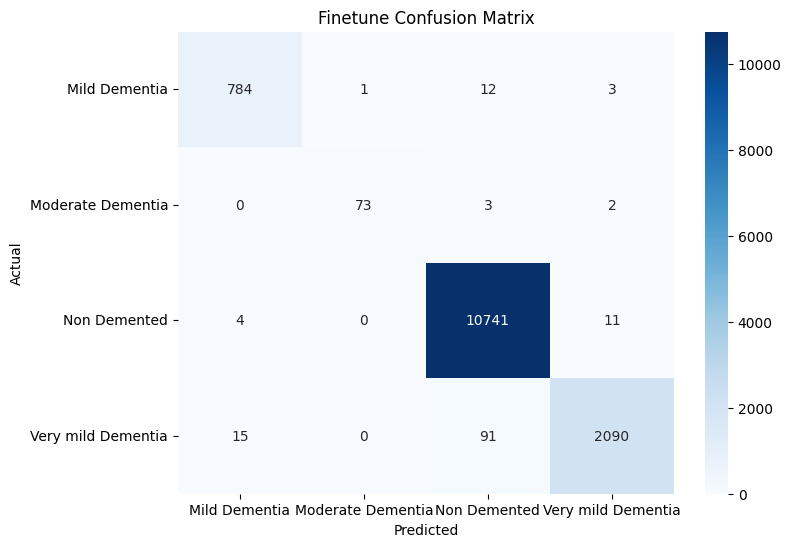

[train-ft] batch=0 loss=0.0100 acc=0.9961
[train-ft] batch=100 loss=0.0051 acc=0.9980


Validation: |          | 0/? [00:00<?, ?it/s]


📊 FINETUNE VALIDATION RESULTS FOR EPOCH 4
Accuracy: 99.07%

Classification Report:

                    precision    recall  f1-score   support

     Mild Dementia       0.97      0.99      0.98       800
 Moderate Dementia       0.99      0.97      0.98        78
      Non Demented       1.00      0.99      0.99     10756
Very mild Dementia       0.96      1.00      0.98      2196

          accuracy                           0.99     13830
         macro avg       0.98      0.99      0.98     13830
      weighted avg       0.99      0.99      0.99     13830


Confusion Matrix:



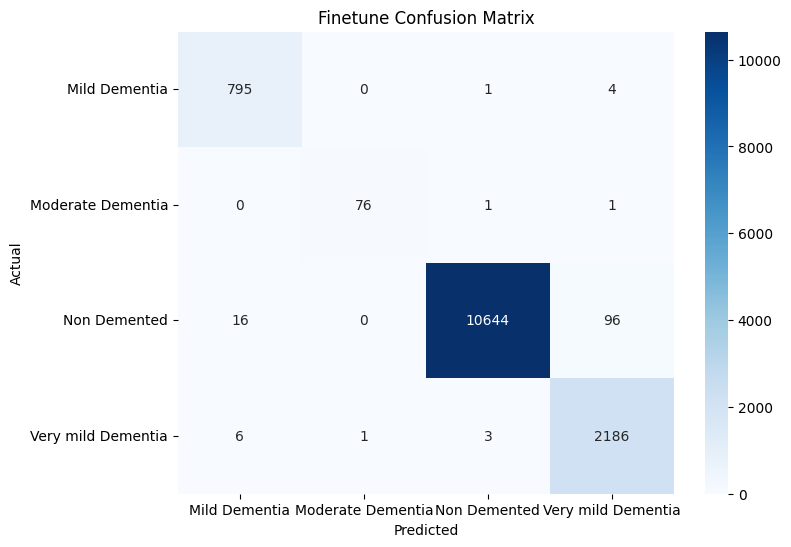

[train-ft] batch=0 loss=0.0109 acc=0.9941
[train-ft] batch=100 loss=0.0033 acc=1.0000


Validation: |          | 0/? [00:00<?, ?it/s]


📊 FINETUNE VALIDATION RESULTS FOR EPOCH 5
Accuracy: 99.63%

Classification Report:

                    precision    recall  f1-score   support

     Mild Dementia       0.99      0.99      0.99       800
 Moderate Dementia       1.00      0.96      0.98        78
      Non Demented       1.00      1.00      1.00     10756
Very mild Dementia       0.99      0.99      0.99      2196

          accuracy                           1.00     13830
         macro avg       1.00      0.98      0.99     13830
      weighted avg       1.00      1.00      1.00     13830


Confusion Matrix:



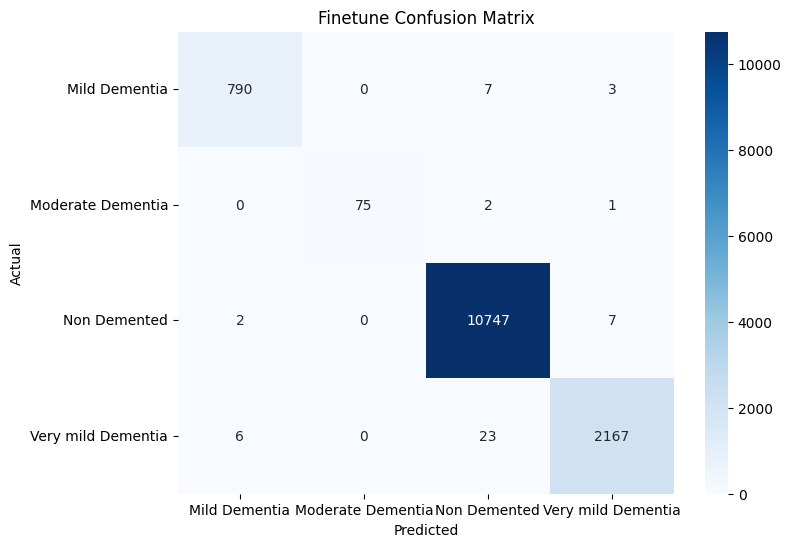

[train-ft] batch=0 loss=0.0049 acc=0.9980
[train-ft] batch=100 loss=0.0008 acc=1.0000


Validation: |          | 0/? [00:00<?, ?it/s]


📊 FINETUNE VALIDATION RESULTS FOR EPOCH 6
Accuracy: 99.74%

Classification Report:

                    precision    recall  f1-score   support

     Mild Dementia       1.00      0.99      0.99       800
 Moderate Dementia       1.00      0.96      0.98        78
      Non Demented       1.00      1.00      1.00     10756
Very mild Dementia       0.99      1.00      0.99      2196

          accuracy                           1.00     13830
         macro avg       1.00      0.99      0.99     13830
      weighted avg       1.00      1.00      1.00     13830


Confusion Matrix:



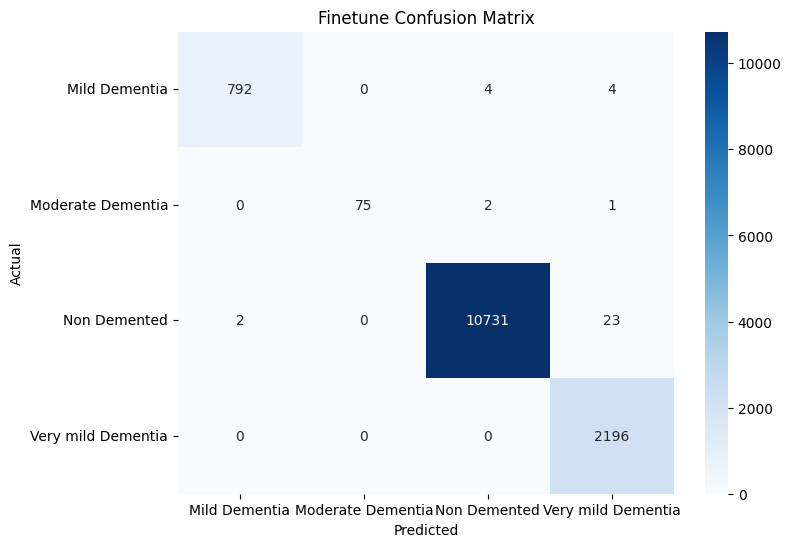

[train-ft] batch=0 loss=0.0006 acc=1.0000
[train-ft] batch=100 loss=0.0003 acc=1.0000


Validation: |          | 0/? [00:00<?, ?it/s]


📊 FINETUNE VALIDATION RESULTS FOR EPOCH 7
Accuracy: 99.83%

Classification Report:

                    precision    recall  f1-score   support

     Mild Dementia       0.99      0.99      0.99       800
 Moderate Dementia       1.00      0.96      0.98        78
      Non Demented       1.00      1.00      1.00     10756
Very mild Dementia       0.99      1.00      1.00      2196

          accuracy                           1.00     13830
         macro avg       1.00      0.99      0.99     13830
      weighted avg       1.00      1.00      1.00     13830


Confusion Matrix:



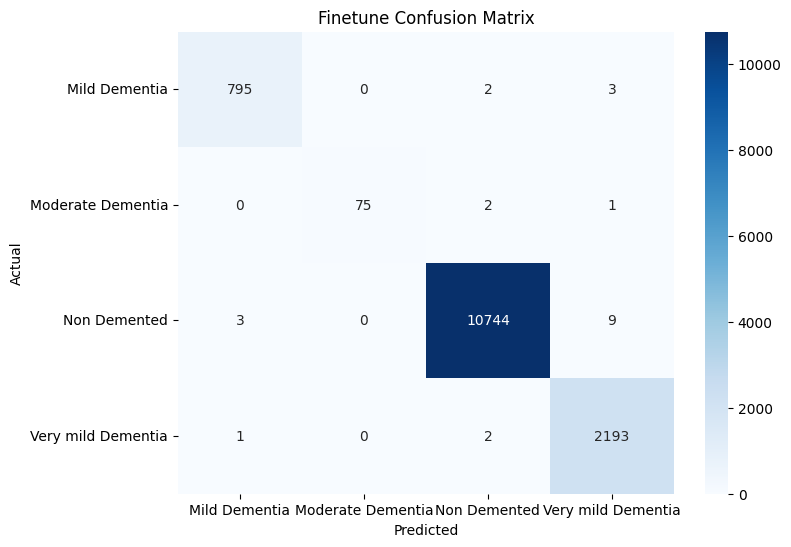

[train-ft] batch=0 loss=0.0002 acc=1.0000
[train-ft] batch=100 loss=0.0004 acc=1.0000


Validation: |          | 0/? [00:00<?, ?it/s]


📊 FINETUNE VALIDATION RESULTS FOR EPOCH 8
Accuracy: 99.85%

Classification Report:

                    precision    recall  f1-score   support

     Mild Dementia       1.00      0.99      0.99       800
 Moderate Dementia       1.00      0.97      0.99        78
      Non Demented       1.00      1.00      1.00     10756
Very mild Dementia       0.99      1.00      1.00      2196

          accuracy                           1.00     13830
         macro avg       1.00      0.99      0.99     13830
      weighted avg       1.00      1.00      1.00     13830


Confusion Matrix:



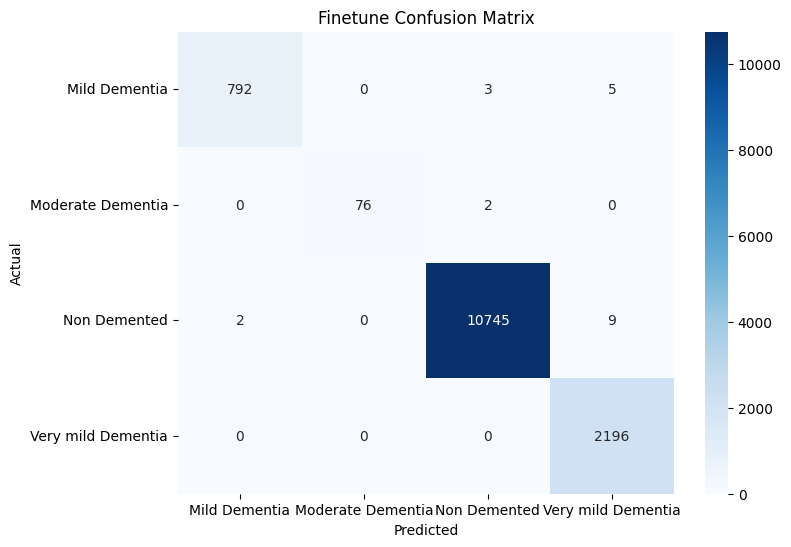

[train-ft] batch=0 loss=0.0002 acc=1.0000
[train-ft] batch=100 loss=0.0001 acc=1.0000


Validation: |          | 0/? [00:00<?, ?it/s]


📊 FINETUNE VALIDATION RESULTS FOR EPOCH 9
Accuracy: 99.86%

Classification Report:

                    precision    recall  f1-score   support

     Mild Dementia       0.99      0.99      0.99       800
 Moderate Dementia       1.00      0.97      0.99        78
      Non Demented       1.00      1.00      1.00     10756
Very mild Dementia       1.00      1.00      1.00      2196

          accuracy                           1.00     13830
         macro avg       1.00      0.99      0.99     13830
      weighted avg       1.00      1.00      1.00     13830


Confusion Matrix:



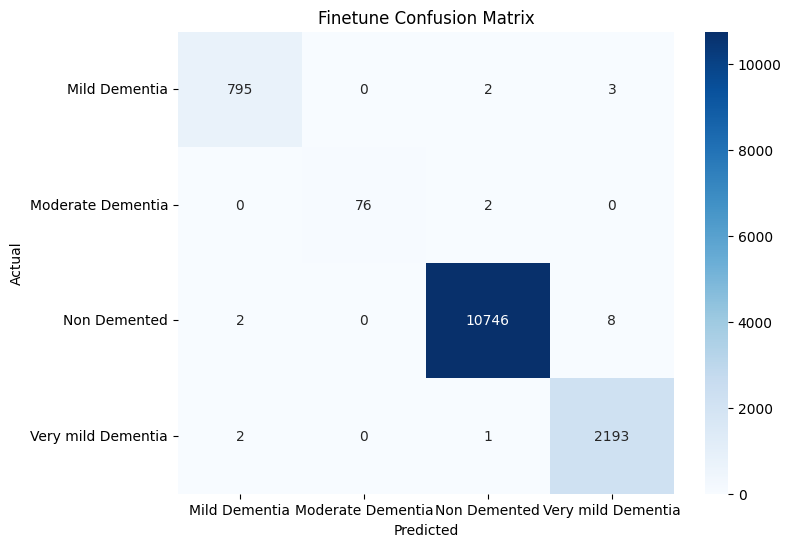

[train-ft] batch=0 loss=0.0002 acc=1.0000
[train-ft] batch=100 loss=0.0002 acc=1.0000


Validation: |          | 0/? [00:00<?, ?it/s]


📊 FINETUNE VALIDATION RESULTS FOR EPOCH 10
Accuracy: 99.87%

Classification Report:

                    precision    recall  f1-score   support

     Mild Dementia       1.00      0.99      1.00       800
 Moderate Dementia       1.00      0.97      0.99        78
      Non Demented       1.00      1.00      1.00     10756
Very mild Dementia       0.99      1.00      1.00      2196

          accuracy                           1.00     13830
         macro avg       1.00      0.99      0.99     13830
      weighted avg       1.00      1.00      1.00     13830


Confusion Matrix:



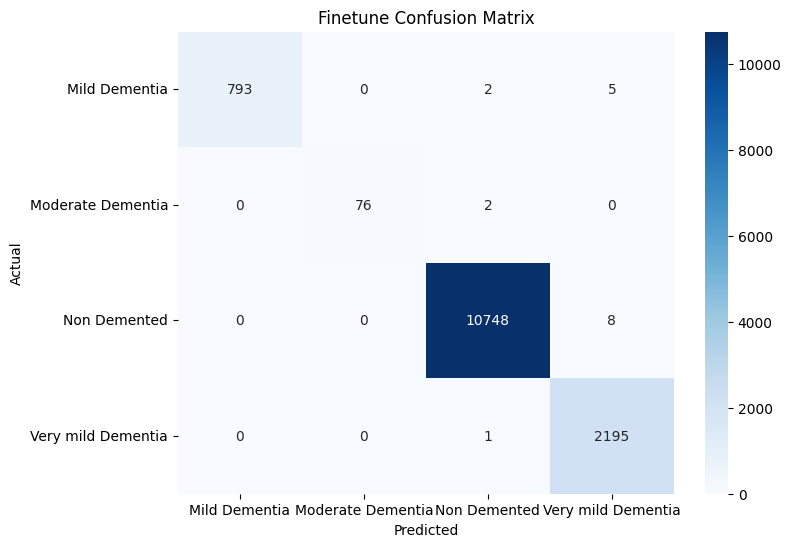

[train-ft] batch=0 loss=0.0001 acc=1.0000
[train-ft] batch=100 loss=0.0000 acc=1.0000


Validation: |          | 0/? [00:00<?, ?it/s]


📊 FINETUNE VALIDATION RESULTS FOR EPOCH 11
Accuracy: 99.83%

Classification Report:

                    precision    recall  f1-score   support

     Mild Dementia       0.99      0.99      0.99       800
 Moderate Dementia       1.00      0.99      0.99        78
      Non Demented       1.00      1.00      1.00     10756
Very mild Dementia       0.99      1.00      1.00      2196

          accuracy                           1.00     13830
         macro avg       1.00      0.99      1.00     13830
      weighted avg       1.00      1.00      1.00     13830


Confusion Matrix:



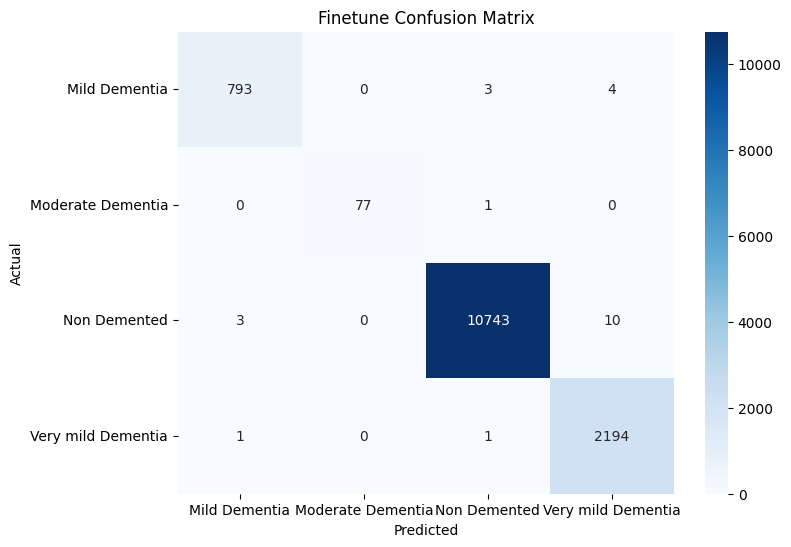

[train-ft] batch=0 loss=0.0001 acc=1.0000
[train-ft] batch=100 loss=0.0001 acc=1.0000


Validation: |          | 0/? [00:00<?, ?it/s]


📊 FINETUNE VALIDATION RESULTS FOR EPOCH 12
Accuracy: 99.84%

Classification Report:

                    precision    recall  f1-score   support

     Mild Dementia       0.99      0.99      0.99       800
 Moderate Dementia       1.00      0.99      0.99        78
      Non Demented       1.00      1.00      1.00     10756
Very mild Dementia       0.99      1.00      1.00      2196

          accuracy                           1.00     13830
         macro avg       1.00      0.99      1.00     13830
      weighted avg       1.00      1.00      1.00     13830


Confusion Matrix:



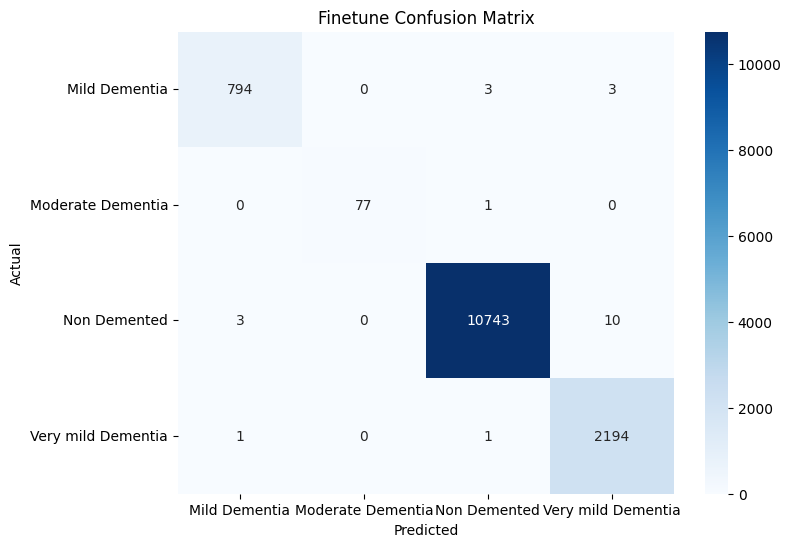

[train-ft] batch=0 loss=0.0000 acc=1.0000
[train-ft] batch=100 loss=0.0001 acc=1.0000


Validation: |          | 0/? [00:00<?, ?it/s]


📊 FINETUNE VALIDATION RESULTS FOR EPOCH 13
Accuracy: 99.86%

Classification Report:

                    precision    recall  f1-score   support

     Mild Dementia       0.99      0.99      0.99       800
 Moderate Dementia       1.00      0.99      0.99        78
      Non Demented       1.00      1.00      1.00     10756
Very mild Dementia       0.99      1.00      1.00      2196

          accuracy                           1.00     13830
         macro avg       1.00      1.00      1.00     13830
      weighted avg       1.00      1.00      1.00     13830


Confusion Matrix:



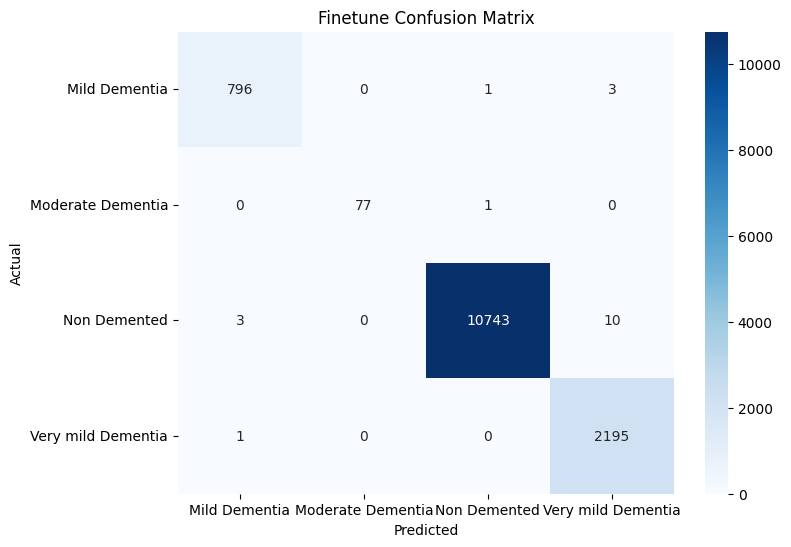

[train-ft] batch=0 loss=0.0001 acc=1.0000
[train-ft] batch=100 loss=0.0000 acc=1.0000


Validation: |          | 0/? [00:00<?, ?it/s]


📊 FINETUNE VALIDATION RESULTS FOR EPOCH 14
Accuracy: 99.85%

Classification Report:

                    precision    recall  f1-score   support

     Mild Dementia       1.00      0.99      0.99       800
 Moderate Dementia       1.00      0.99      0.99        78
      Non Demented       1.00      1.00      1.00     10756
Very mild Dementia       0.99      1.00      1.00      2196

          accuracy                           1.00     13830
         macro avg       1.00      0.99      1.00     13830
      weighted avg       1.00      1.00      1.00     13830


Confusion Matrix:



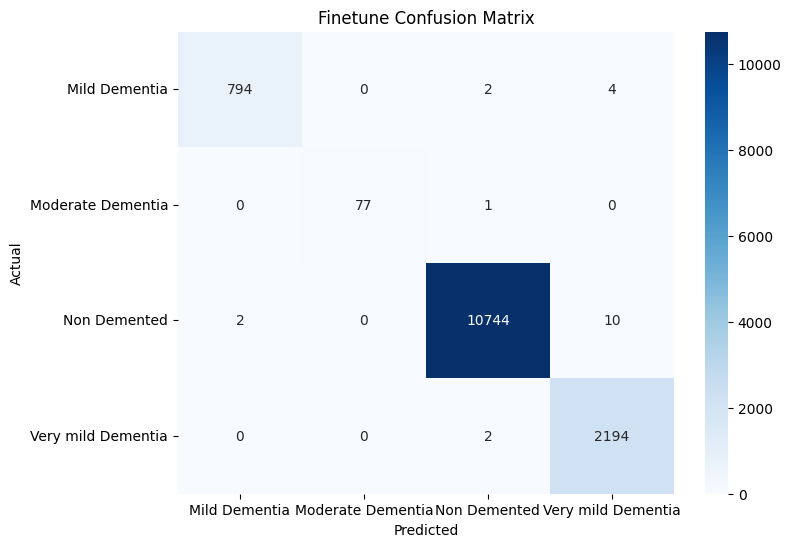

/home/zeus/miniconda3/envs/cloudspace/lib/python3.12/site-packages/pytorch_lightning/trainer/connectors/checkpoint_connector.py:149: `.test(ckpt_path=None)` was called without a model. The best model of the previous `fit` call will be used. You can pass `.test(ckpt_path='best')` to use the best model or `.test(ckpt_path='last')` to use the last model. If you pass a value, this warning will be silenced.
Restoring states from the checkpoint path at /teamspace/studios/this_studio/finetuned_checkpoints_Kaggle/alzheimer-vit-FINETUNE-epoch=10-val_acc=0.9987.ckpt


✅ Finetuning finished.

🔬 Starting FINAL TEST on 'test' folder...


LOCAL_RANK: 0 - CUDA_VISIBLE_DEVICES: [0]
Loaded model weights from the checkpoint at /teamspace/studios/this_studio/finetuned_checkpoints_Kaggle/alzheimer-vit-FINETUNE-epoch=10-val_acc=0.9987.ckpt


Testing: |          | 0/? [00:00<?, ?it/s]


🔬 FINAL TEST RESULTS ON 'test' FOLDER (AFTER FINETUNING)
Accuracy: 99.82%

Classification Report:

                    precision    recall  f1-score   support

     Mild Dementia       1.00      1.00      1.00      1001
 Moderate Dementia       1.00      0.99      0.99        98
      Non Demented       1.00      1.00      1.00     13445
Very mild Dementia       1.00      0.99      1.00      2745

          accuracy                           1.00     17289
         macro avg       1.00      0.99      1.00     17289
      weighted avg       1.00      1.00      1.00     17289


Confusion Matrix:



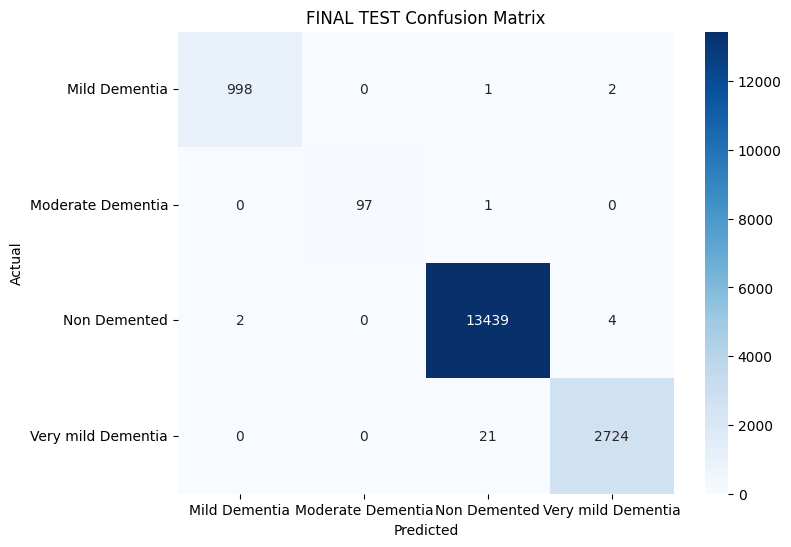

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━━━━┓
┃        Test metric        ┃       DataLoader 0        ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━━━━┩
│          val_acc          │    0.9982069730758667     │
│         val_loss          │   0.005619627423584461    │
└───────────────────────────┴───────────────────────────┘

✅ Testing complete.


In [21]:
import os
import torch
import numpy as np
import seaborn as sns
import matplotlib.pyplot as plt
from sklearn.metrics import accuracy_score, confusion_matrix, classification_report
from sklearn.model_selection import train_test_split # For stratified split
from torchvision import datasets, transforms
from torch.utils.data import DataLoader, Subset # For splitting
import torch.nn.functional as F
import pytorch_lightning as pl
from pytorch_lightning.callbacks import ModelCheckpoint, EarlyStopping
import timm

# ----------------------------------------------------------------------
# 1. 3-CHANNEL MODEL DEFINITION
# (This MUST match the class structure your checkpoint was saved with)
# ----------------------------------------------------------------------
class AlzheimerViT(pl.LightningModule):
    def __init__(self, num_classes, lr=1e-4, classes_list=None):
        super().__init__()
        self.save_hyperparameters()
        self.model = timm.create_model("vit_base_patch16_224", pretrained=True, num_classes=num_classes)
        self.lr = lr
        self.class_names = classes_list if classes_list is not None else [str(i) for i in range(num_classes)]

        # These will be used for both validation and testing steps
        self.step_outputs = [] 

    def forward(self, x):
        return self.model(x)

    def training_step(self, batch, batch_idx):
        images, labels = batch
        outputs = self(images)
        loss = F.cross_entropy(outputs, labels)
        preds = outputs.argmax(dim=1)
        acc = (preds == labels).float().mean()

        if batch_idx % 100 == 0:
            print(f"[train-ft] batch={batch_idx} loss={loss.item():.4f} acc={acc.item():.4f}")

        self.log('train_loss', loss, prog_bar=False, on_step=True, on_epoch=True)
        self.log('train_acc', acc, prog_bar=False, on_step=True, on_epoch=True)
        return loss

    def validation_step(self, batch, batch_idx):
        images, labels = batch
        outputs = self(images)
        loss = F.cross_entropy(outputs, labels)
        preds = outputs.argmax(dim=1)
        
        # Store preds and labels for epoch end
        self.step_outputs.append({'preds': preds.detach().cpu(), 'labels': labels.detach().cpu()})
        
        self.log('val_loss', loss, prog_bar=True, on_step=False, on_epoch=True)
        self.log('val_acc', (preds == labels).float().mean(), prog_bar=True, on_step=False, on_epoch=True)
        return loss

    # This hook is called by trainer.fit() at the end of each validation epoch
    def on_validation_epoch_end(self):
        if not self.step_outputs:
            print("\nSkipping validation epoch end, no outputs.")
            return

        preds = torch.cat([x['preds'] for x in self.step_outputs], dim=0).numpy()
        labels = torch.cat([x['labels'] for x in self.step_outputs], dim=0).numpy()
        self.step_outputs.clear() # Clear for the next epoch

        print("\n" + "="*60)
        print(f"📊 FINETUNE VALIDATION RESULTS FOR EPOCH {self.current_epoch}")
        print("="*60)
        
        self._print_metrics(labels, preds, "Finetune Confusion Matrix")
        
    # This hook is called by trainer.test()
    def test_step(self, batch, batch_idx):
        # Re-use validation logic for testing
        return self.validation_step(batch, batch_idx)

    def on_test_epoch_end(self):
        if not self.step_outputs:
            print("\nNo test predictions found.")
            return
            
        preds = torch.cat([x['preds'] for x in self.step_outputs], dim=0).numpy()
        labels = torch.cat([x['labels'] for x in self.step_outputs], dim=0).numpy()
        self.step_outputs.clear() # Clear after testing

        print("\n" + "="*70)
        print("🔬 FINAL TEST RESULTS ON 'test' FOLDER (AFTER FINETUNING)")
        print("="*70)
        
        self._print_metrics(labels, preds, "FINAL TEST Confusion Matrix")

    # Helper function to print metrics
    def _print_metrics(self, labels, preds, plot_title):
        acc = accuracy_score(labels, preds)
        print(f"Accuracy: {acc*100:.2f}%\n")

        print("Classification Report:\n")
        all_class_indices = list(range(len(self.class_names)))
        report = classification_report(
            labels, 
            preds, 
            target_names=self.class_names, 
            labels=all_class_indices,
            zero_division=0
        )
        print(report)

        print("\nConfusion Matrix:\n")
        cm = confusion_matrix(labels, preds)
        plt.figure(figsize=(8, 6))
        sns.heatmap(cm, annot=True, fmt='d', cmap='Blues',
                    xticklabels=self.class_names, yticklabels=self.class_names)
        plt.xlabel('Predicted')
        plt.ylabel('Actual')
        plt.title(plot_title)
        plt.show()
        print("="*60)
        
    def configure_optimizers(self):
        return torch.optim.AdamW(self.parameters(), lr=self.lr)

# -------------------------------------------------------------
# STEP 2: CONFIGURATION
# -------------------------------------------------------------
TRAIN_DATA_ROOT = "train" 
TEST_DATA_ROOT = "test"
CHECKPOINT_PATH = '/teamspace/studios/this_studio/lightning_logs/version_0/checkpoints/alzheimer-vit-epoch=03-val_acc=0.9740.ckpt'

# ⚠️ --- OPTIMIZATION 1: Increased BATCH_SIZE for H100 ---
BATCH_SIZE = 512 # Was 32. Lower to 256 or 128 if you get memory errors
# ---------------------------------------------------------

IMG_SIZE = 224
NUM_WORKERS = 4
LR = 1e-5       # Using a smaller learning rate for finetuning
MAX_EPOCHS = 20 
SEED = 42
VAL_SPLIT_SIZE = 0.2 # 80% train, 20% validation

device = "cuda" if torch.cuda.is_available() else "cpu"
pl.seed_everything(SEED)

# Transforms
train_transform = transforms.Compose([
    transforms.Resize((IMG_SIZE, IMG_SIZE)),
    transforms.RandomHorizontalFlip(),
    transforms.ToTensor(),
    transforms.Normalize([0.485, 0.456, 0.406], [0.229, 0.224, 0.225])
])

val_transform = transforms.Compose([
    transforms.Resize((IMG_SIZE, IMG_SIZE)),
    transforms.ToTensor(),
    transforms.Normalize([0.485, 0.456, 0.406], [0.229, 0.224, 0.225])
])

# -------------------------------------------------------------
# STEP 3: DATA LOADING (Train/Val and Test)
# -------------------------------------------------------------
print(f"Loading new training data from: {TRAIN_DATA_ROOT}...")

# --- Train/Val Datasets (from 'train' folder) ---
full_dataset = datasets.ImageFolder(
    root=TRAIN_DATA_ROOT,
    transform=train_transform
)
classes_found = full_dataset.classes
num_classes = len(classes_found)
print(f"✅ Found {len(full_dataset)} training images in {num_classes} classes:")
print(classes_found)

all_labels = full_dataset.targets
all_indices = np.arange(len(all_labels))
train_indices, val_indices = train_test_split(
    all_indices,
    test_size=VAL_SPLIT_SIZE,
    stratify=all_labels,
    random_state=SEED
)

train_dataset = Subset(full_dataset, train_indices)
val_full_dataset = datasets.ImageFolder(root=TRAIN_DATA_ROOT, transform=val_transform)
val_dataset = Subset(val_full_dataset, val_indices)
print("✅ Training data split using stratification.")
print(f"📦 New Train size: {len(train_dataset)} | New Val size: {len(val_dataset)}")

# --- Test Dataset (from 'test' folder) ---
print(f"\nLoading new test data from: {TEST_DATA_ROOT}...")
test_dataset = datasets.ImageFolder(
    root=TEST_DATA_ROOT,
    transform=val_transform
)
print(f"✅ Found {len(test_dataset)} test images.")


# --- DataLoaders ---
train_loader = DataLoader(train_dataset, batch_size=BATCH_SIZE, shuffle=True, num_workers=NUM_WORKERS, pin_memory=True)
val_loader = DataLoader(val_dataset, batch_size=BATCH_SIZE, shuffle=False, num_workers=NUM_WORKERS, pin_memory=True)
test_loader = DataLoader(test_dataset, batch_size=BATCH_SIZE, shuffle=False, num_workers=NUM_WORKERS, pin_memory=True)


# -------------------------------------------------------------
# STEP 4: MODEL LOADING & FINETUNING
# -------------------------------------------------------------
print(f"\n🔥 Loading model from checkpoint: {CHECKPOINT_PATH}")

if not os.path.exists(CHECKPOINT_PATH):
    print(f"🚨 ERROR: Checkpoint file not found at {CHECKPOINT_PATH}")
    print("Please update the CHECKPOINT_PATH variable to the correct file path.")
else:
    # Load the model directly from the checkpoint
    model = AlzheimerViT.load_from_checkpoint(
        CHECKPOINT_PATH,
        map_location=device,
        num_classes=num_classes, 
        lr=LR, # Use the new finetuning LR
        classes_list=classes_found
    )
    
    print("✅ 3-Channel model and weights loaded successfully.")
    
    # Define NEW callbacks for the finetuning run
    finetune_checkpoint_cb = ModelCheckpoint(
        monitor='val_acc',
        mode='max',
        save_top_k=1,
        filename='alzheimer-vit-FINETUNE-{epoch:02d}-{val_acc:.4f}',
        dirpath='finetuned_checkpoints_Kaggle' # Save to a new folder
    )
    finetune_earlystop_cb = EarlyStopping(monitor='val_acc', patience=4, mode='max')

    # Create a new Trainer for finetuning
    trainer = pl.Trainer(
        # ⚠️ --- OPTIMIZATION 2: Use Mixed Precision for H100 ---
        precision='16-mixed',
        # ---------------------------------------------------------
        max_epochs=MAX_EPOCHS,
        accelerator='auto',
        devices=1 if torch.cuda.is_available() else None,
        callbacks=[finetune_checkpoint_cb, finetune_earlystop_cb],
        log_every_n_steps=10
    )

    print("\n🧠 Starting FINETUNING on 'train' folder...")
    trainer.fit(model, train_loader, val_loader)
    print("✅ Finetuning finished.")

    # -------------------------------------------------------------
    # STEP 5: FINAL TESTING
    # -------------------------------------------------------------
    print("\n🔬 Starting FINAL TEST on 'test' folder...")
    # The trainer automatically uses the best checkpoint saved during .fit()
    trainer.test(dataloaders=test_loader)
    print("✅ Testing complete.")